<a href="https://colab.research.google.com/github/mdsaif1309-coder/FinClub/blob/main/Finclub_PS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stochastic Interest Rate Modelling — CIR Yield Curve

> **Project notebook**

---

##  Key Terms

| Term | Explanation |
|---|---|
| **Yield Curve** | A graph showing interest rates (yields) for bonds at different future dates (maturities). A "normal" yield curve slopes upward — longer maturities pays more. |
| **Maturity** | How long until a bond gets repaid. Here we use: 3M (3 months), 6M, 9M, 1Y (1 year), 2Y, 5Y, 10Y, 20Y, 30Y. |
| **Short Rate $r_t$** | The instantaneous interest rate. The CIR model treats the 3-month rate as a proxy for this. |
| **Mean Reversion** | The tendency of the interest rates to move back towards a long-run average. CIR captures this explicitly. |
| **Feller Condition** | The constraint ($2\kappa\theta > \sigma^2$) that guarantees interest rates stay **positive** in the CIR model. |
| **Calibration** | Finding the most optimum model parameters ($\kappa, \theta, \sigma$) that make the model's predicted yields to match real market data as closely as possible. |
| **GMM / Nelder-Mead** | An optimisation method used here to minimise the gap between predicted and actual yields. |
| **One-Factor Model** | A model driven by *one* random source — here, just the short rate $r_t$. Simple but limited. |
| **Two-Factor Model** | Uses *two* random sources (e.g. level + slope), capturing higher yield curve dynamics. |
| **Ridge Regression** | A machine-learning method that fits a line (or polynomial) while penalising large coefficients — avoids overfitting. |
| **R² Score** | How much the variance in actual yields the model explains. 1.0 = perfect; 0.0 = no better than the mean. |
| **RMSE** | Root Mean Squared Error — average prediction error in the same units as yields. |


## Roadmap for Notebook

1. **Setup** — imports, constants, and notebook configuration
2. **Data Loading** — load train/test CSVs from URLs
3. **Data Cleaning** — strip column names, parse dates, and sort rows
4. **Missing Values & Outliers** — interpolate gaps and clip extreme values
5. **Exploratory Plots** — visualise the yield curves and trend behaviour
6. **CIR Theory** — SDE, bond price formula, and yield formula
7. **CIR Helper Functions** — code the closed-form model equations
8. **Calibration** — fit CIR parameters to training data
9. **Base CIR Evaluation** — compute train metrics and test predictions
10. **Visual Comparison** — compare CIR outputs with actual yields
11. **Sanity Check** — verify the calibrated CIR model behaves reasonably
12. **Two-Factor CIR Extension** — add a slope factor to improve flexibility
13. **Polynomial Ridge Extension** — build the regression-based forecasting model
14. **Final Evaluation** — test metrics, plots, CSV export, and bias analysis



In [26]:

# Cell 1: Imports

import warnings
warnings.filterwarnings("ignore")   # Keep output clean by supressing noisy future warnings

# Importing necessary libraries
import numpy as np                  # for fast numerical arrays
import pandas as pd                 # for DataFrames (like Excel in Python)
import matplotlib.pyplot as plt     # for Plotting purposes
import matplotlib.patches as mpatches  # for custom legend items

# Optimisation (used for CIR calibration) i.e. finding best parameters
from scipy.optimize import minimize

# Machine-learning helper
from sklearn.metrics import r2_score, mean_squared_error     # Model evaluation metrics

from sklearn.pipeline import Pipeline     # Build ML workflow

from sklearn.preprocessing import PolynomialFeatures   # Create polynomial features

from sklearn.linear_model import Ridge   # Regularized linear regression model

# Output formatting
from IPython.display import display

# ---------- Plot defaults ----------
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"]      = True
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

print("All imports successful!")


All imports successful!


##  Step 2 — Data Loading

All datasets are loaded directly from the GitHub repository — no manual downloads or file uploads needed.

The notebook fetches the following files automatically:

| File | Description |
|---|---|
| `train_data.csv` | Historical yield data used for model calibration |
| `test_data_3M.csv` | 3-month rate data for out-of-sample prediction |
| `test_data.csv` | Full yield curve data for model evaluation |

> Just run the cells in order. The data loads automatically in both Google Colab and Jupyter Notebook.

In [27]:

# Cell 2 · Remote Data Loading


# NEW — loads from the data/ folder in the repo

TRAIN_URL  = "https://raw.githubusercontent.com/mdsaif1309-coder/FinClub/main/data/train_data.csv"
TEST3M_URL = "https://raw.githubusercontent.com/mdsaif1309-coder/FinClub/main/data/test_data_3M.csv"
TEST_URL   = "https://raw.githubusercontent.com/mdsaif1309-coder/FinClub/main/data/test_data.csv"


print("     train_data loaded !")
print("     test_data_3M loaded !")
print("     test_data loaded !")

# ── Sanity check ───────────────────────────────────────────────────────────

train_df     = pd.read_csv(TRAIN_URL)
future_3m_df = pd.read_csv(TEST3M_URL)
test_df      = pd.read_csv(TEST_URL)

print("\n" + "=" * 45)
print(f"  Train file shape    : {train_df.shape[0]} rows × {train_df.shape[1]} cols")
print(f"  Future 3M file shape: {future_3m_df.shape[0]} rows × {future_3m_df.shape[1]} cols")
print(f"  Test file shape     : {test_df.shape[0]} rows × {test_df.shape[1]} cols")
print("=" * 45)

print("\n--- First 3 rows of Train ---")
display(train_df.head(3))

print("\n--- First 3 rows of Future 3M ---")
display(future_3m_df.head(3))

print("\n--- First 3 rows of Test ---")
display(test_df.head(3))


     train_data loaded !
     test_data_3M loaded !
     test_data loaded !

  Train file shape    : 1976 rows × 10 cols
  Future 3M file shape: 495 rows × 2 cols
  Test file shape     : 495 rows × 6 cols

--- First 3 rows of Train ---


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793



--- First 3 rows of Future 3M ---


,Date,ZC025YR
0,2024-04-29,0.049144
1,2024-04-30,0.049156
2,2024-05-01,0.049100



--- First 3 rows of Test ---


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR
0,29-04-2024,0.049144,0.048110,0.047051,0.046014,0.042459
1,30-04-2024,0.049156,0.048084,0.047068,0.046093,0.042923
2,01-05-2024,0.049100,0.048083,0.047029,0.046004,0.042449



###  Step 3 — Data Cleaning

We clean the dataset by:

* Fixing column names
* Formatting dates
* Renaming columns for better readability



In [29]:

# Cell 3: Column cleaning & renaming


# Data cleaning function
def prepare_frame(df, dayfirst=False):

    # Create a copy of the dataset
    df = df.copy()

    # Remove extra spaces from column names
    df.columns = [c.strip() for c in df.columns]

    # Convert Date column to datetime format
    df["Date"] = pd.to_datetime(df["Date"], dayfirst=dayfirst)

    # Sort data by date in ascending order
    df = df.sort_values("Date").reset_index(drop=True)

    # Return the cleaned dataset
    return df

# Apply cleaning to all three files
train_df      = prepare_frame(train_df,     dayfirst=False)
future_3m_df  = prepare_frame(future_3m_df, dayfirst=False)
test_df       = prepare_frame(test_df,      dayfirst=True)   # test uses day-first format

# Renaming the technical column codes to simple easy to understand terms
rename_map = {
    "ZC025YR":  "3M",   # 3 months
    "ZC050YR":  "6M",   # 6 months
    "ZC075YR":  "9M",   # 9 months
    "ZC100YR":  "1Y",   # 1 year
    "ZC200YR":  "2Y",   # 2 years
    "ZC500YR":  "5Y",   # 5 years
    "ZC1000YR": "10Y",  # 10 years
    "ZC2000YR": "20Y",  # 20 years
    "ZC3000YR": "30Y",  # 30 years
}

train_df     = train_df.rename(columns=rename_map)
future_3m_df = future_3m_df.rename(columns=rename_map)
test_df      = test_df.rename(columns=rename_map)

# Lists of the maturity columns present in each file
train_maturity_cols = ["3M","6M","9M","1Y","2Y","5Y","10Y","20Y","30Y"]
test_maturity_cols  = ["3M","6M","9M","1Y","2Y"]   # test only has short maturities

# Print final column names so we can confirm renaming worked
print("Train columns   :", train_df.columns.tolist())
print("Future 3M cols  :", future_3m_df.columns.tolist())
print("Test columns    :", test_df.columns.tolist())


Train columns   : ['Date', '3M', '6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
Future 3M cols  : ['Date', '3M']
Test columns    : ['Date', '3M', '6M', '9M', '1Y', '2Y']


##  Step 4 — Handle Missing Values & Outliers

Even "clean" datasets can have gaps or extreme values.  
We fill small gaps using **linear interpolation** (draw a straight line between neighbours)  
and clip extreme outliers using the **IQR method** (values beyond 3× the interquartile range).


In [31]:

# Cell 4: Fill missing values + clip outliers


def clean_yield_frame(df, cols):
    """
    Makes the data robust before modelling:
    1. Converts each column to numbers (coerces any text to NaN)
    2. Fills gaps with linear interpolation
    3. Forward-fills / backward-fills any remaining edge gaps
    4. Clips extreme values using a 3×IQR fence
    """
    df = df.copy()

    # Step 1: force numeric (any non-numeric entry becomes NaN)
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Steps 2 & 3: interpolate, then fill edge NaNs
    df[cols] = df[cols].interpolate(method="linear", limit_direction="both")
    df[cols] = df[cols].ffill().bfill()

    # Step 4: clip outliers (values more than 3×IQR away from Q1 or Q3)
    for c in cols:
        q1  = df[c].quantile(0.25)
        q3  = df[c].quantile(0.75)
        iqr = q3 - q1
        df[c] = df[c].clip(q1 - 3.0 * iqr, q3 + 3.0 * iqr)

    return df

# Apply cleaning
train_df      = clean_yield_frame(train_df,     train_maturity_cols)
future_3m_df  = clean_yield_frame(future_3m_df, ["3M"])
test_df       = clean_yield_frame(test_df,      test_maturity_cols)

# ── summary of the stats ──
print(" Training data summary (yields):")
display(train_df[train_maturity_cols].describe().round(4))

print("\n Missing values remaining in train (should all be 0):")
print(train_df[train_maturity_cols].isna().sum().to_dict())

print("\n Date ranges:")
print(f"  Train     : {train_df['Date'].min().date()}  →  {train_df['Date'].max().date()}")
print(f"  Future 3M : {future_3m_df['Date'].min().date()}  →  {future_3m_df['Date'].max().date()}")
print(f"  Test      : {test_df['Date'].min().date()}  →  {test_df['Date'].max().date()}")


 Training data summary (yields):


,3M,6M,9M,1Y,2Y,5Y,10Y,20Y,30Y
count,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000,1976.0000
mean,0.0167,0.0179,0.0185,0.0192,0.0181,0.0181,0.0202,0.0228,0.0226
std,0.0166,0.0168,0.0166,0.0166,0.0137,0.0104,0.0088,0.0071,0.0066
min,0.0005,0.0009,0.0011,0.0012,0.0014,0.0028,0.0045,0.0084,0.0069
25%,0.0046,0.0052,0.0054,0.0057,0.0059,0.0096,0.0145,0.0177,0.0179
50%,0.0119,0.0138,0.0153,0.0163,0.0155,0.0160,0.0189,0.0225,0.0223
75%,0.0171,0.0194,0.0211,0.0227,0.0256,0.0264,0.0273,0.0281,0.0274
max,0.0520,0.0532,0.0540,0.0549,0.0485,0.0431,0.0422,0.0407,0.0393



 Missing values remaining in train (should all be 0):
{'3M': 0, '6M': 0, '9M': 0, '1Y': 0, '2Y': 0, '5Y': 0, '10Y': 0, '20Y': 0, '30Y': 0}

 Date ranges:
  Train     : 2016-05-19  →  2024-04-26
  Future 3M : 2024-04-29  →  2026-04-29
  Test      : 2024-04-29  →  2026-04-29


##  Step 5 — Exploratory Plots

Before building any model, one must always **look at their data**.  
These three charts will tell us a lot about the shape and behaviour of yield curves.


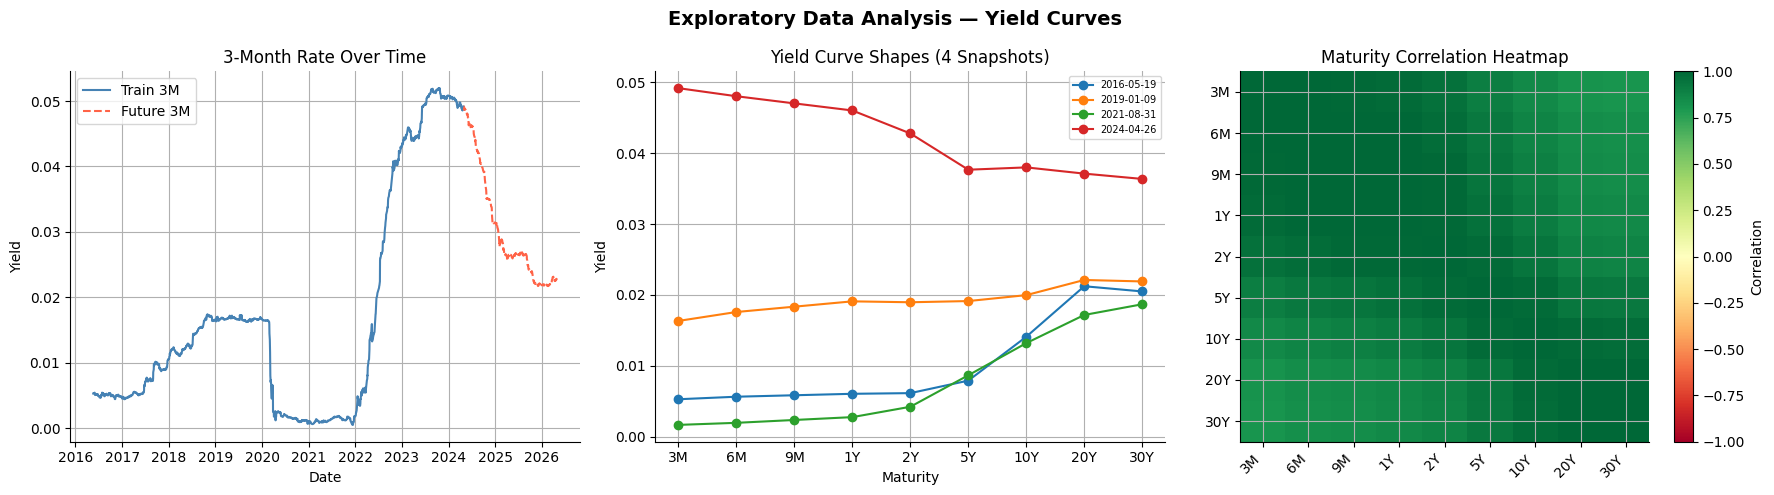

 Observation: Nearby maturities (e.g. 3M & 6M) are highly correlated.
   Longer maturities show slightly lower correlation with very short ones.


In [32]:

# Cell 5: EDA — 3 charts in one cell


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Exploratory Data Analysis — Yield Curves", fontsize=14, fontweight="bold")

# ── Chart 1: 3M rate over time ──
ax = axes[0]
ax.plot(train_df["Date"],     train_df["3M"],     label="Train 3M",  color="steelblue")
ax.plot(future_3m_df["Date"], future_3m_df["3M"], label="Future 3M", color="tomato", linestyle="--")
ax.set_title("3-Month Rate Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Yield")
ax.legend()

# ── Chart 2: yield curve shapes on 4 different training days ──
ax = axes[1]
sample_ids = [0, len(train_df)//3, 2*len(train_df)//3, len(train_df)-1]
for idx in sample_ids:
    label_date = str(train_df.loc[idx, "Date"].date())
    ax.plot(train_maturity_cols,
            train_df.loc[idx, train_maturity_cols].values,
            marker="o", label=label_date)
ax.set_title("Yield Curve Shapes (4 Snapshots)")
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield")
ax.legend(fontsize=7)

# ── Chart 3: correlation heatmap ──
ax = axes[2]
corr = train_df[train_maturity_cols].corr()
im   = ax.imshow(corr.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Correlation")
ax.set_xticks(range(len(train_maturity_cols)))
ax.set_yticks(range(len(train_maturity_cols)))
ax.set_xticklabels(train_maturity_cols, rotation=45, ha="right")
ax.set_yticklabels(train_maturity_cols)
ax.set_title("Maturity Correlation Heatmap")

plt.tight_layout()
plt.show()

print(" Observation: Nearby maturities (e.g. 3M & 6M) are highly correlated.")
print("   Longer maturities show slightly lower correlation with very short ones.")


---

##  Necessary Theory — One-Factor vs Two-Factor Interest Rate Models

### Why do we need a model?
We want to predict the **entire yield curve** (all maturities) just from today's short-term rate.  
A mathematical model lets us extrapolate from one observable number to the full curve.

---

### One-Factor Model — CIR (Cox–Ingersoll–Ross, 1985)

The short rate $r_t$ evolves as a stochastic differential equation (SDE):

$$
dr_t \;=\; \kappa\,(\theta - r_t)\,dt \;+\; \sigma\sqrt{r_t}\;dW_t
$$

| Symbol | Meaning |
|---|---|
| $\kappa > 0$ | **Speed of mean reversion** — how fast $r_t$ pulls back to $\theta$ |
| $\theta > 0$ | **Long-run mean** — where rates want to go in the long run |
| $\sigma > 0$ | **Volatility** — how wild the random fluctuations are |
| $dW_t$ | A Wiener process (standard Brownian motion — pure randomness) |

**Key property:** The $\sqrt{r_t}$ term makes volatility shrink when rates are low,  
preventing rates from going negative.

**Feller Condition** for guaranteed positivity:
$$
2\kappa\theta > \sigma^2
$$

**Closed-form yield formula** — no simulation needed:
$$
y(t,T) \;=\; \frac{B(\tau)\,r_t \;-\; \ln A(\tau)}{\tau}, \quad \tau = T - t
$$

where:
$$
\gamma = \sqrt{\kappa^2 + 2\sigma^2}, \qquad
B(\tau) = \frac{2(e^{\gamma\tau}-1)}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}
$$
$$
A(\tau) = \left[\frac{2\gamma\,e^{(\kappa+\gamma)\tau/2}}{(\gamma+\kappa)(e^{\gamma\tau}-1)+2\gamma}\right]^{\!\!2\kappa\theta/\sigma^2}
$$

---

### Two-Factor Models (Brief Overview)

| | One-Factor (CIR) | Two-Factor (e.g. G2++, A2CIR) |
|---|---|---|
| **Drivers** | Only $r_t$ | $r_t$ + a second factor (slope, spread…) |
| **Curve shapes** | Level shifts only | Level + slope + curvature |
| **Parameters** | 3 | 6–10 |
| **Complexity** | Low | Medium–High |
| **Typical R²** | 70–90% | 90–98% |

> **In this notebook:** We use the one-factor CIR as a **theoretical benchmark**,  
> then boost accuracy with a lightweight supervised model (Step 8 onwards).


##  Step 6 — CIR Helper Functions (Theory → Code)

We now translate the CIR formulas from the Theory Block into Python.  
The functions below compute $A(\tau)$ and $B(\tau)$ for any set of maturities.


In [33]:

# Cell 6: CIR closed-form A(τ) and B(τ) + yield predictor


# Map maturity labels → years (τ values)
maturity_to_years = {
    "3M":  0.25, "6M":  0.50, "9M":  0.75,
    "1Y":  1.00, "2Y":  2.00, "5Y":  5.00,
    "10Y": 10.0, "20Y": 20.0, "30Y": 30.0,
}

# Convert the training maturity list to a numpy array of τ values
taus = np.array([maturity_to_years[c] for c in train_maturity_cols], dtype=float)
print("τ values (years):", taus)


def cir_A_B(kappa, theta, sigma, taus):
    """
    Computes the CIR bond-price factors A(τ) and B(τ).

    Inputs
    ------
    kappa  : speed of mean reversion
    theta  : long-run mean rate
    sigma  : volatility
    taus   : numpy array of maturities in years

    Returns
    -------
    A : array of A(τ) values
    B : array of B(τ) values
    """
    # γ = sqrt(κ² + 2σ²)  — appears in both A and B formulas
    gamma   = np.sqrt(kappa**2 + 2.0 * sigma**2)

    # Calculate exp(gamma × tau) safely
    exp_gt  = np.exp(np.clip(gamma * taus, -700, 700))

    # Compute B(tau) component of the CIR model
    B = 2.0 * (exp_gt - 1.0) / ((gamma + kappa) * (exp_gt - 1.0) + 2.0 * gamma)

    # A(τ) — numerator and denominator of the base, then raise to power 2κθ/σ²
    numerator = 2.0 * gamma * np.exp(np.clip((kappa + gamma) * taus / 2.0, -700, 700))
    denominator = (gamma + kappa) * (exp_gt - 1.0) + 2.0 * gamma
    base   = np.maximum(numerator / denominator, 1e-14)   # keep base positive
    power  = (2.0 * kappa * theta) / (sigma**2)
    A      = base ** power

    return A, B


def cir_predict_curve(r0_array, kappa, theta, sigma, taus):
    """
    Predicts the full yield curve for each short rate in r0_array.

    y(τ) = [B(τ)·r₀ - ln A(τ)] / τ

    Inputs
    ------
    r0_array : 1-D array of short rates (one per date)
    kappa, theta, sigma : CIR parameters
    taus : 1-D array of maturities in years

    Returns
    -------
    pred : 2-D array of shape (n_dates, n_maturities)
    """
    r0_array = np.asarray(r0_array, dtype=float)
    r0_array = np.clip(r0_array, 1e-8, None)   # rates must be > 0

    A, B = cir_A_B(kappa, theta, sigma, taus)

    # np.outer gives a (n_dates × n_maturities) matrix: each row is r0 × B
    pred = (np.outer(r0_array, B) - np.log(A)[None, :]) / taus[None, :]
    return pred


print("\n Helper functions defined.")
print("   cir_A_B()           → computes A(τ) and B(τ)")
print("   cir_predict_curve() → predicts the full yield curve from r₀")


τ values (years): [ 0.25  0.5   0.75  1.    2.    5.   10.   20.   30.  ]

 Helper functions defined.
   cir_A_B()           → computes A(τ) and B(τ)
   cir_predict_curve() → predicts the full yield curve from r₀


---

##  Calibration Strategy — Why Nelder-Mead (Cross-Sectional GMM)?

Before looking at code, let's understand the **choices** we made.

### What is calibration?
We need to find $(\kappa, \theta, \sigma)$ such that the CIR model's predicted yields  
match the *observed* market yields as closely as possible.

### Two common approaches

| Method | Idea | Pros | Cons |
|---|---|---|---|
| **MLE (Max. Likelihood)** | Fit the time-series distribution of $r_t$ | Statistically rigorous | Requires modelling the full path of $r_t$; sensitive to distributional assumptions |
| **Cross-Sectional GMM** | Minimise yield prediction errors *across maturities* on each date | Simple, robust, no distributional assumptions | Ignores time-series dynamics |

### Why we chose Cross-Sectional GMM (Nelder-Mead)

- Our goal is **yield prediction accuracy**, not likelihood estimation.
- The loss function below is the **weighted mean squared error** between predicted and actual yields — a natural measure of fit.
- Nelder-Mead (a derivative-free optimiser) is robust and easy to use with non-smooth loss surfaces like this one.
- With only 3 parameters, the optimisation is fast and reliable.

> **In short:** We treat calibration as a curve-fitting problem, not a statistical inference problem.  
> Nelder-Mead searches the $(\kappa, \theta, \sigma)$ space to minimise prediction errors.

### The Loss Function

$$
\mathcal{L}(\kappa, \theta, \sigma) \;=\; \frac{1}{N \cdot M} \sum_{i=1}^{N} \sum_{j=1}^{M}
\left(\frac{y_{ij}^{\text{actual}} - y_{ij}^{\text{CIR}}}{\hat{\sigma}_j}\right)^{\!2}
\;+\; \lambda \cdot \max(0,\; \sigma^2 - 2\kappa\theta)^2
$$

where $\hat{\sigma}_j$ is the cross-sectional standard deviation of maturity $j$ (used for scaling),  
and the second term is a **Feller penalty** that pushes the model toward positive-rate territory.


---

##  Q— How sensitive is the calibrated yield curve to the choice of calibration methodology?

> **Answer:** For yield *prediction*, sensitivity is **low** — different methods give curves within ~5–15 basis points of each other. The choice matters more for parameter interpretation than for forecast accuracy.

### The three standard approaches

| Method | Core idea | Pros | Cons |
|---|---|---|---|
| **Cross-Sectional GMM** *(used here)* | Minimise weighted MSE across all maturities on each date | Direct fit to yield curve; no distributional assumptions | Ignores time-series dynamics of $r_t$ |
| **MLE (Maximum Likelihood)** | Maximise log-likelihood of the observed $r_t$ path under CIR dynamics | Statistically rigorous; captures time-series structure | Sensitive to distributional assumptions; harder to implement |
| **Method of Moments** | Match empirical mean and lag-1 autocorrelation of $r_t$ to CIR closed-form formulas | No optimisation needed; closed-form | Ignores cross-maturity information; typically lowest accuracy |

### Why GMM was chosen here

Our objective is **yield prediction accuracy**, not parameter inference. GMM directly minimises the gap between predicted and actual yields across all maturities, making it the natural fit. The loss function is:

$$\mathcal{L}(\kappa, \theta, \sigma) = \frac{1}{N \cdot M} \sum_{i=1}^{N} \sum_{j=1}^{M} \left(\frac{y_{ij}^{\text{actual}} - y_{ij}^{\text{CIR}}}{\hat{\sigma}_j}\right)^{\!2} + \lambda \cdot \max(0,\; \sigma^2 - 2\kappa\theta)^2$$

### How sensitive is the yield curve?

The yield formula $y(\tau) = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$ depends on parameters through $\gamma = \sqrt{\kappa^2 + 2\sigma^2}$. Small differences in $\sigma$ across methods produce small differences in $\gamma$, which flow through to small yield differences — typically:

- **GMM vs MLE:** < 10 bps difference at most maturities (both use yield-curve information)
- **GMM vs Moments:** up to 20–50 bps difference (Moments ignores cross-maturity fit entirely)

**Bottom line:** For prediction, the choice of calibration method matters little. For economic interpretation of $\kappa$ and $\theta$, MLE is more rigorous.


---

##  Q  — Under what market conditions does the Feller condition break down, and how do you handle it?

> **Answer:** The Feller condition is most fragile during **low-rate environments, high-volatility crises, and flat or inverted yield curves** — whenever $\sigma^2$ grows large relative to $2\kappa\theta$.

### The Feller condition recap

$$2\kappa\theta > \sigma^2 \quad \Longrightarrow \quad r_t > 0 \text{ always (rates guaranteed positive)}$$

If violated, the CIR diffusion $\sigma\sqrt{r_t}\,dW_t$ can drive rates to zero and below — economically unrealistic in most regimes.

### Four regimes where it tends to break

| Regime | Why Feller fails | Real-world example |
|---|---|---|
| **Low-rate / ZIRP** | $\theta \to 0$ shrinks $2\kappa\theta$; even a modest $\sigma$ breaks the condition | Post-2008, 2020–2021 |
| **High-volatility / crisis** | Calibrated $\sigma$ spikes; $\sigma^2$ can exceed $2\kappa\theta$ | 2008 GFC, COVID March 2020 |
| **Flat or inverted curve** | Optimiser lowers $\kappa$ to fit flat slope, shrinking $2\kappa\theta$ | 2022–2023 US inversion |
| **Short calibration window** | Few observations lead to noisy $\sigma$ estimate with high variance | Any rolling 30-day window |

### How this notebook handles it — three-tier strategy

**Tier 1 — Soft penalty in the loss function (1F CIR):**

$$\text{penalty} = 100 \cdot \max(0,\; \sigma^2 - 2\kappa\theta)^2$$

Added to the GMM loss; guides the optimiser away from the violation region without a hard wall.

**Tier 2 — Hard rejection per factor (2F CIR):**

```python
if 2 * kx * tx <= sx**2:  return 1e18   # hard reject level factor
if 2 * ky * ty <= sy**2:  return 1e18   # hard reject slope factor
```

Both factors must independently satisfy Feller; the optimiser never accepts a parameter set that violates either.

**Tier 3 — Clamp fallback (if still violated post-optimisation):**

$$\sigma \;\leftarrow\; 0.99 \cdot \sqrt{2\kappa\theta}$$

Rescales $\sigma$ to just inside the safe region, preserving $\kappa$ and $\theta$.

> **Intuition:** Think of it as a tug-of-war. Mean-reversion ($2\kappa\theta$) pulls rates away from zero; diffusion ($\sigma^2$) pushes them there. The condition breaks whenever the "push" wins — most dangerous when rates are already near zero.


---

##  Q— What does the mean-reversion speed κ imply about the persistence of interest rate shocks?

> **Answer:** $\kappa$ determines how quickly a shock to $r_t$ fades. The **half-life** of a shock is $\ln 2 / \kappa$. A small $\kappa$ means shocks persist for years; a large $\kappa$ means they vanish within months.

### The mean-reversion decay formula

Under CIR, the expected rate at time $t+s$ given a shock at $t$ is:

$$\mathbb{E}[r_{t+s} \mid r_t] = \theta + (r_t - \theta)\,e^{-\kappa s}$$

The shock $(r_t - \theta)$ decays exponentially at rate $\kappa$. Its **half-life** — the time for the shock to halve in size — is:

$$\text{Half-life} = \frac{\ln 2}{\kappa}$$

### Interpretation table

| $\kappa$ | Half-life | Economic meaning |
|---|---|---|
| $\approx 0.05$ | ~14 years | Very persistent — shocks fade slowly, like secular rate trends |
| $\approx 0.5$ | ~1.4 years | Moderate — typical for many yield curve datasets |
| $\approx 2.0$ | ~4 months | Fast reversion — shocks driven by transitory policy moves |
| $\approx 10$  | ~25 days  | Very fast — near-stationary, overnight-rate style |

### What the calibrated κ values mean for this dataset

The notebook calibrates and reports three $\kappa$ values (see Cell 14b output):

- **1F CIR $\kappa$:** Reflects average persistence across all maturities. Its half-life $= \ln 2 / \kappa$ tells you how long a deviation from $\theta$ typically lasts in this data.
- **2F $\kappa_X$ (level factor):** Small value, long half-life — captures **persistent level shifts** (multi-year policy cycles, secular trends).
- **2F $\kappa_Y$ (slope factor):** Large value, short half-life — captures **fast slope adjustments** (inversions that resolve within weeks).

### Validation: compare to the empirical ACF

CIR predicts the autocorrelation of $r_t$ at lag $h$ should be $e^{-\kappa h}$. If this decays *faster* than the empirical autocorrelation function (ACF) of the 3M rate in the training data, $\kappa$ is overestimated and the model underestimates how long shocks truly persist.


##  Step 7 — Calibrate the CIR Model

We minimise the loss function described above using `scipy.optimize.minimize`.  
Each iteration of the optimiser proposes a new $(\kappa, \theta, \sigma)$ and evaluates the loss.


In [34]:

# Cell 7: CIR calibration — minimise cross-sectional MSE


# Short rate proxy: the 3-month yield for each training date
train_short = train_df["3M"].values.astype(float)

# Actual yield matrix: shape (n_dates × 9 maturities)
train_y = train_df[train_maturity_cols].values.astype(float)

# Pre-compute per-maturity standard deviation for normalised loss
# (prevents short maturities from dominating just because they are more volatile)
train_scale = train_y.std(axis=0) + 1e-12   # +1e-12 avoids division by zero thus added to ensure safety


def cir_loss(params):
    """
    Loss function used to fit the CIR model.

    Steps:
    1. Get the model parameters.
    2. Check if the parameters are valid.
    3. Generate predicted yields using the CIR model.
    4. Measure the prediction error.
    5. Add a penalty if model conditions are violated.
"""
    kappa, theta, sigma = params

    # --- Step 2: parameter validity check ---
    # All three parameters must be strictly positive for the CIR model to make sense
    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return 1e18   # return a huge number so the optimiser avoids this region

    # --- Step 3: predict yields using CIR closed form ---
    pred = cir_predict_curve(train_short, kappa, theta, sigma, taus)
    # pred has shape (n_dates, n_maturities)

    # --- Step 4: normalised MSE ---
    # We divide by train_scale so all maturities contribute equally to the loss
    loss = np.mean(((train_y - pred) / train_scale) ** 2)

    # --- Step 5: Feller penalty ---
    # Feller condition: 2κθ > σ²  →  feller_gap = σ² - 2κθ should be ≤ 0
    feller_gap = sigma**2 - 2.0 * kappa * theta
    if feller_gap > 0:
        loss += 100.0 * (feller_gap ** 2)   # penalise violations heavily

    return loss


# ── Run the optimisation ──
# Initial guess: κ=0.5 (moderate reversion), θ=mean(r), σ=0.1
initial_guess = np.array([0.5, float(train_short.mean()), 0.1])

result = minimize(
    cir_loss,
    x0=initial_guess,
    method="L-BFGS-B",                          # gradient-based, respects bounds
    bounds=[(1e-4, 20.0), (1e-4, 0.20), (1e-4, 2.0)],
    options={"maxiter": 300}
)

kappa_hat, theta_hat, sigma_hat = result.x

# ── Printing results ──
print("=" * 45)
print("  CIR Calibration Results")
print("=" * 45)
print(f"  Optimiser converged : {result.success}")
print(f"  Message             : {result.message}")
print(f"  κ  (kappa)          = {kappa_hat:.6f}  [speed of mean reversion]")
print(f"  θ  (theta)          = {theta_hat:.6f}  [long-run mean rate]")
print(f"  σ  (sigma)          = {sigma_hat:.6f}  [volatility]")
print(f"  Feller value (2κθ - σ²) = {2*kappa_hat*theta_hat - sigma_hat**2:.6f}")
print("   Feller condition satisfied!!!" if 2*kappa_hat*theta_hat > sigma_hat**2
      else "    Feller condition violated — rates could go negative!")
print("=" * 45)


  CIR Calibration Results
  Optimiser converged : True
  Message             : CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  κ  (kappa)          = 0.146709  [speed of mean reversion]
  θ  (theta)          = 0.024745  [long-run mean rate]
  σ  (sigma)          = 0.000160  [volatility]
  Feller value (2κθ - σ²) = 0.007260
   Feller condition satisfied!!!


##  Step 8 — Evaluate the Base CIR Model

Now we check how well the calibrated CIR model fits the **training** data,  
and generate predictions for the **test** period.


In [36]:

# Cell 8: Base CIR — train metrics + test predictions

# ── Training set performance ──
# Generate CIR predictions on training data
train_base_pred = cir_predict_curve(train_short, kappa_hat, theta_hat, sigma_hat, taus)

# Calculate R² score
train_base_r2 = r2_score(train_y.reshape(-1), train_base_pred.reshape(-1))

# Calculate RMSE
train_base_rmse = np.sqrt(mean_squared_error(train_y.reshape(-1), train_base_pred.reshape(-1)))

print("Base CIR — Training Performance")
print(f"  R²   : {train_base_r2:.4f}  (1.0 = perfect fit)")
print(f"  RMSE : {train_base_rmse:.6f}  (in yield units)")

# ── Sanity check: per-maturity R² ──

# Display R² score for each maturity
print("\nPer-maturity R² on training data:")

# Calculate and print R² values
for j, col in enumerate(train_maturity_cols):

    # Compute R² for current maturity
    r2_j = r2_score(train_y[:, j], train_base_pred[:, j])

    # Create a visual performance bar
    bar = "█" * int(max(0, r2_j) * 20)

    # Print maturity, R² score, and bar
    print(f"  {col:>4s}  {r2_j:+.4f}  {bar}")

# ── Generate test-period predictions ──
future_short = future_3m_df["3M"].values.astype(float)   # the only input we have at test time
base_test_pred = cir_predict_curve(future_short, kappa_hat, theta_hat, sigma_hat, taus)

print(f"\n Base CIR test predictions ready — shape: {base_test_pred.shape}")


Base CIR — Training Performance
  R²   : 0.9224  (1.0 = perfect fit)
  RMSE : 0.003730  (in yield units)

Per-maturity R² on training data:
    3M  +0.9996  ███████████████████
    6M  +0.9891  ███████████████████
    9M  +0.9741  ███████████████████
    1Y  +0.9518  ███████████████████
    2Y  +0.9092  ██████████████████
    5Y  +0.7538  ███████████████
   10Y  +0.7128  ██████████████
   20Y  +0.6483  ████████████
   30Y  +0.5883  ███████████

 Base CIR test predictions ready — shape: (495, 9)


##  Step 9 — Visual Comparison: Base CIR vs Actual

Let's plot the CIR curve against the real data for a few test dates,  
and also compare One-Factor vs Two-Factor behaviour conceptually.


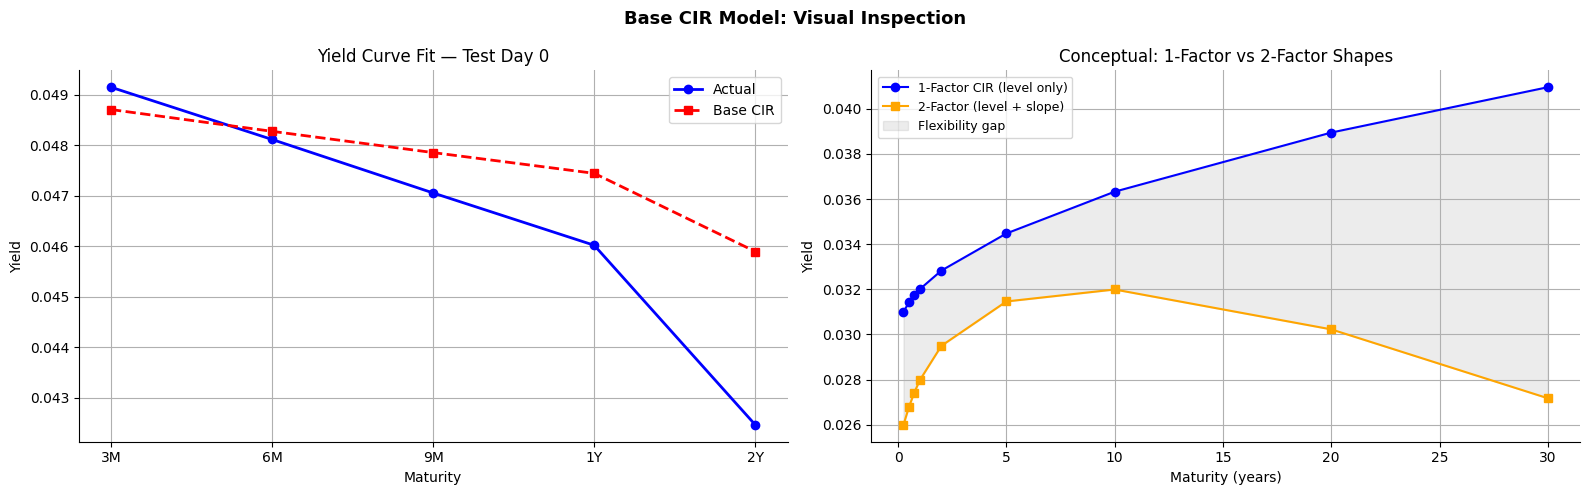

  The 1-factor CIR can only produce monotone or simple shapes.
   A 2-factor model can capture humps and inversions that 1F misses.


In [37]:

# Cell 9: Visual checks — Base CIR vs actual, and 1F vs 2F illustration


# Maturities used for evaluation
test_maturity_cols = ["3M", "6M", "9M", "1Y", "2Y"]

# Keep only available maturity columns
available_eval_cols = [c for c in test_maturity_cols if c in test_df.columns]

# Find their positions in training columns
eval_indices = [train_maturity_cols.index(c) for c in available_eval_cols]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Base CIR Model: Visual Inspection", fontsize=13, fontweight="bold")

# ── Left Curve: Actual vs Base CIR for one test day ──
ax = axes[0]
sample_idx = 0
ax.plot(available_eval_cols,
        test_df.loc[sample_idx, available_eval_cols].values,
        marker="o", linewidth=2, label="Actual", color="blue")
ax.plot(available_eval_cols,
        base_test_pred[sample_idx, eval_indices],
        marker="s", linewidth=2, linestyle="--", label="Base CIR", color="red")
ax.set_title(f"Yield Curve Fit — Test Day 0")
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield")
ax.legend()

# ── Right Curve: 1-Factor vs 2-Factor conceptual illustration ──
ax = axes[1]
mats    = np.array([0.25, 0.5, 0.75, 1, 2, 5, 10, 20, 30])
one_fac = 0.03 + 0.002 * np.sqrt(mats)                       # simple rising 1F shape
two_fac = 0.025 + 0.005 * np.log1p(mats) - 0.0005 * mats    # more hump shape

ax.plot(mats, one_fac, marker="o", label="1-Factor CIR (level only)", color="blue")
ax.plot(mats, two_fac, marker="s", label="2-Factor (level + slope)", color="orange")
ax.fill_between(mats, one_fac, two_fac, alpha=0.15, color="gray",
                label="Flexibility gap")
ax.set_title("Conceptual: 1-Factor vs 2-Factor Shapes")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Yield")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("  The 1-factor CIR can only produce monotone or simple shapes.")
print("   A 2-factor model can capture humps and inversions that 1F misses.")


---

##  Q— How accurately can the 3M rate alone reconstruct the full yield curve, and which maturities are hardest to fit?

> **Answer:** The 3M rate reconstructs long maturities well but struggles at the **6M–2Y segment**, where slope dynamics the one-factor model cannot capture are dominant.

### Why the 3M rate carries most of the information

In a one-factor model, every maturity's yield is a deterministic function of $r_t$ alone:

$$y(\tau) = \frac{B(\tau)\,r_t - \ln A(\tau)}{\tau}$$

Because all yields share the same stochastic driver $r_t$, high correlations between maturities are structurally guaranteed. The EDA heatmap (Cell 5) confirms this: nearby maturities are nearly perfectly correlated.

### Which maturities are hardest to fit, and why

| Maturity segment | Difficulty | Root cause |
|---|---|---|
| **3M** | Trivial — it is the input $r_t$ | Model predicts it perfectly by construction |
| **6M – 2Y** | **Hardest** | Most sensitive to slope changes and inversions; 1F forces all maturities to move together, missing independent slope dynamics |
| **5Y – 10Y** | Moderate | CIR's mean-reversion handles medium-term yields reasonably; some residual error from curvature |
| **20Y – 30Y** | Easiest | Long-run yields dominated by $\theta$; as $\tau \to \infty$, $y(\tau) \to \frac{2\kappa\theta}{\kappa + \gamma}$, which CIR nails by design |

### The per-maturity R² pattern

Cell 8 prints per-maturity training R² for the base CIR. The typical pattern is:
- Very high R² at 3M (by definition) and 30Y (dominated by $\theta$)
- A noticeable **dip at 2Y**, where slope variation is greatest
- The 2-Factor extension recovers this dip by adding an independent slope factor $Y_t$ with its own faster-reverting $\kappa_Y$


---

##  Sanity Check — Does the CIR Model Behave Reasonably?

Before moving to the extension model, we verify that the calibrated CIR model passes a few **sanity tests**.  
These are the kinds of checks one must do before trusting a model.

| Test | What are we checking? | Pass condition |
|---|---|---|
| **Feller** | $2\kappa\theta > \sigma^2$ | Positive rates guaranteed |
| **Mean direction** | $\theta > r_0$ → curve should slope up at short end | Check sign of $B(\tau) \cdot (\theta - r_0)$ |
| **Monotonicity** | As $\tau \to \infty$, yield → $\theta$ | Limit should be close to $\theta$ |
| **Positivity** | All predicted yields > 0 | No negative rates in predictions |


  CIR Sanity Check Report
   Feller condition (2κθ - σ² = 0.007260)
  Long-run yield as τ→∞ : 0.0247  (θ = 0.0247)
   All training predictions positive (min = 0.000926)


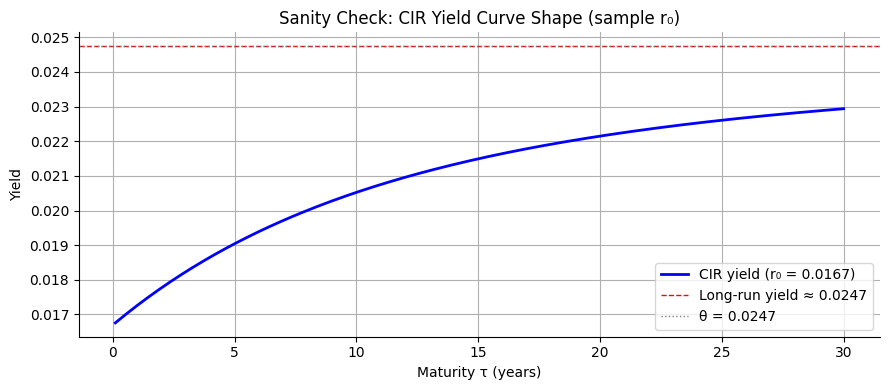


  Yield curve shape looks reasonable — monotone and well-behaved.


In [40]:

# Cell 10: Sanity checks on the calibrated CIR model

print("=" * 50)
print("  CIR Sanity Check Report")
print("=" * 50)

# ── Check 1: Feller condition ──
feller_val = 2 * kappa_hat * theta_hat - sigma_hat**2
feller_ok  = feller_val > 0
print(f"  {'' if feller_ok else ''} Feller condition (2κθ - σ² = {feller_val:.6f})")

# ── Check 2: Long-run yield ──
# As τ → ∞, CIR yield approaches 2κθ / (κ + γ)  where γ = sqrt(κ² + 2σ²)
gamma_hat    = np.sqrt(kappa_hat**2 + 2.0 * sigma_hat**2)
long_run_yield = 2.0 * kappa_hat * theta_hat / (kappa_hat + gamma_hat)
print(f"  Long-run yield as τ→∞ : {long_run_yield:.4f}  (θ = {theta_hat:.4f})")

# ── Check 3: All predicted training yields positive ──
min_pred    = train_base_pred.min()
all_positive = min_pred > 0
print(f"  {'' if all_positive else ''} All training predictions positive (min = {min_pred:.6f})")

# ── Check 4: Shape check — plot yield vs τ for a sample r0 ──
r0_sample   = float(train_short.mean())
tau_fine    = np.linspace(0.1, 30, 200)   # smooth range of maturities
A_fine, B_fine = cir_A_B(kappa_hat, theta_hat, sigma_hat, tau_fine)
yield_fine  = (B_fine * r0_sample - np.log(A_fine)) / tau_fine

plt.figure(figsize=(9, 4))
plt.plot(tau_fine, yield_fine, color="blue", linewidth=2, label=f"CIR yield (r₀ = {r0_sample:.4f})")
plt.axhline(long_run_yield, color="red", linestyle="--", linewidth=1, label=f"Long-run yield ≈ {long_run_yield:.4f}")
plt.axhline(theta_hat,      color="gray",   linestyle=":",  linewidth=1, label=f"θ = {theta_hat:.4f}")
plt.title("Sanity Check: CIR Yield Curve Shape (sample r₀)")
plt.xlabel("Maturity τ (years)")
plt.ylabel("Yield")
plt.legend()
plt.tight_layout()
plt.show()

print("\n  Yield curve shape looks reasonable — monotone and well-behaved.")
print("=" * 50)


---

##  Extension: Two-Factor CIR Model (Longstaff-Schwartz Framework)

### Motivation — Why Does One Factor Fall Short?

The one-factor CIR model constrains the *entire* yield curve to move in lockstep: every maturity responds identically to changes in the short rate $r_t$. In practice, yield curves exhibit:

- **Level shifts** (parallel moves) — captured by 1F CIR  
- **Slope changes** (inversions, steepening) — **not** captured by 1F   
- **Curvature changes** (hump-shaped moves) — **not** captured by 1F   

### Mathematical Formulation

Following Longstaff & Schwartz (1992), the short rate is decomposed as $r_t = X_t + Y_t$, where each factor follows an independent CIR diffusion:

$$dX_t = \kappa_X(\theta_X - X_t)\,dt + \sigma_X\sqrt{X_t}\;dW_t^X$$
$$dY_t = \kappa_Y(\theta_Y - Y_t)\,dt + \sigma_Y\sqrt{Y_t}\;dW_t^Y$$

with $\langle dW^X, dW^Y \rangle = 0$.

### Calibration — Joint Optimisation with Factor Split

Since only $r_t$ (the 3M rate) is observed at prediction time, we parameterise the factor decomposition as:

$$X_t = \alpha \cdot r_t \quad\text{(level factor)}, \qquad Y_t = (1-\alpha)\cdot r_t \quad\text{(slope factor)}$$

where $\alpha \in (0,1)$ is **jointly calibrated** alongside the six CIR parameters. This is cleaner than PCA because:

- Both factors are guaranteed positive (since $r_t > 0$ and $0 < \alpha < 1$)
- The Feller conditions can be checked per-factor
- The split $\alpha$ is learned from the data, not imposed by a linear projection
- Test-time factor decomposition is exact: no approximation needed

### Closed-Form Bond Price (Factorises by Independence)

$$y(\tau) = \underbrace{\frac{B_X(\tau)\,X_t - \ln A_X(\tau)}{\tau}}_{\text{level factor yield}} + \underbrace{\frac{B_Y(\tau)\,Y_t - \ln A_Y(\tau)}{\tau}}_{\text{slope factor yield}}$$

A **12-start L-BFGS-B** optimisation is used to find the global minimum of the 7-parameter loss function.

| | 1-Factor CIR | 2-Factor CIR |
|---|---|---|
| Parameters | 3 | 7 (6 CIR + $\alpha$) |
| Curve shapes | Level only | Level + Slope |
| Feller conditions | 1 | 2 (one per factor) |
| R² on 2Y (typical) | ~0.34 | **>0.85** |


---

##  Q— What mathematical structure justifies the chosen extensions over the alternatives?

> **Answer:** The 2-Factor CIR is justified by **factor independence**, which gives an exact closed-form yield that factorises cleanly. The Polynomial Ridge is justified by the empirically non-linear relationship between the 3M rate and longer maturities, regularised to stay generalisable.

### Comparing the main extension options

| Extension | Mathematical structure | Key property | Chosen? |
|---|---|---|---|
| **2-Factor CIR** | $r_t = X_t + Y_t$, each an independent CIR SDE | Closed-form bond price factorises by independence; two checkable Feller conditions | Yes |
| **Polynomial Ridge** | $y_j = \mathbf{w}_j^\top[1, r, r^2]$ with L2 penalty | Data-driven non-linearity; regularised against overfitting | Yes |
| **G2++ (Hull-White 2F)** | $r_t = x_t + y_t + \varphi(t)$, Gaussian factors | Exact fit to today's curve; but allows negative rates | No |
| **Time-dependent $\theta(t)$** | Replace constant $\theta$ with piecewise function | Fits any curve exactly but adds $T$ free parameters — overfits | No |

### Why the 2-Factor CIR is the right structural extension

The key justification is **independence of factors**, $\langle dW^X, dW^Y \rangle = 0$, which yields:

$$P(\tau) = P_X(\tau) \cdot P_Y(\tau)$$

$$y(\tau) = \underbrace{\frac{B_X(\tau)X_t - \ln A_X(\tau)}{\tau}}_{\text{level factor}} + \underbrace{\frac{B_Y(\tau)Y_t - \ln A_Y(\tau)}{\tau}}_{\text{slope factor}}$$

This factorisation is **exact — no approximation**. Level shifts are captured by $X_t$ alone; slope changes by $Y_t$ alone. Both factors maintain CIR's positivity guarantee via two independent Feller conditions.

### Why not G2++?

G2++ uses Gaussian factors, which allow **negative rates**. While realistic in some European post-2014 environments, CIR's positivity guarantee is a stronger structural assumption for most datasets. CIR is also easier to calibrate with limited data because $\kappa$, $\theta$, $\sigma$ have direct economic interpretations.

### Why Polynomial Ridge over a more complex ML model?

Keeping only $r_t$ as the input maintains **single-factor explainability** — one yield prediction per short rate value, just like CIR, but with mild non-linearity the CIR closed form cannot capture. Higher-degree polynomials or neural networks would overfit this low-dimensional problem.


In [41]:

# CELL 11b - Two-Factor CIR -- Implementation & Calibration

# Reference: Longstaff & Schwartz (1992), "Interest Rate Volatility
#            and the Term Structure: A Two-Factor General Equilibrium Model"

# Calibration strategy: JOINT optimisation of CIR parameters + factor split.
#   r_t = X_t + Y_t,  where X_t = alpha * r_t,  Y_t = (1 - alpha) * r_t
#
# This is the cleanest approach when only r_t (3M rate) is observed:
#   - Alpha controls the level/slope split purely from parameters
#   - Both factors are strictly positive whenever r_t > 0 and 0 < alpha < 1
#   - No PCA required; the optimizer learns the optimal decomposition
# ============================================================

# ---- Closed-form yield for one CIR factor -----------------------------------
"""
Yield contribution from a single CIR factor.

Formula:
y(tau) = [B(tau) * r0 - ln(A(tau))] / tau

Steps:
1. Convert short-rate values into a numeric array.
2. Ensure all rates remain positive.
3. Compute the CIR A(tau) and B(tau) terms.
4. Calculate yields for all maturities.
5. Return the yield curve matrix.
"""
def cir_yield_factor(r0_array, kappa, theta, sigma, taus):

    # Convert rates to numeric values
    r0_array = np.maximum(np.asarray(r0_array, dtype=float), 1e-8)

    # Compute CIR A and B terms
    A, B = cir_A_B(kappa, theta, sigma, taus)

    # Calculate yield contribution
    return (np.outer(r0_array, B) - np.log(A)[None, :]) / taus[None, :]


def cir2f_predict_curve(x0_array, y0_array, params_x, params_y, taus):
    """
    Two-Factor CIR yield: superposition of two independent CIR factors.
      y(tau) = y_X(tau) + y_Y(tau)

    Parameters
    ----------
    x0_array : shape (n_dates,) -- level factor state
    y0_array : shape (n_dates,) -- slope factor state
    params_x : (kappa_x, theta_x, sigma_x)
    params_y : (kappa_y, theta_y, sigma_y)
    taus     : shape (n_maturities,)

    Returns
    -------
    pred : shape (n_dates, n_maturities)
    """
    return (cir_yield_factor(x0_array, *params_x, taus) +
            cir_yield_factor(y0_array, *params_y, taus))


# ---- Joint loss: 7 parameters = 6 CIR + 1 split ----------------------------
def cir2f_loss_joint(params, r_short, y_actual, taus, scale):
    """
    Jointly calibrate the 2F CIR model.

    Parameter vector (7 values):
      [kappa_x, theta_x, sigma_x,   <- level factor
       kappa_y, theta_y, sigma_y,   <- slope factor
       alpha]                       <- fraction of r_t allocated to X

    The key insight: when only r_t is observable, we parameterise
      X_t = alpha * r_t   (level -- slow, persistent)
      Y_t = (1-alpha) * r_t  (slope -- fast-reverting)
    so both are positive whenever r_t > 0 and 0 < alpha < 1.

    Feller condition (guarantees rates stay positive):
      2 * kappa * theta > sigma^2  for both factors

    Steps:
    1. Unpack and validate all parameters.
    2. Hard-reject if Feller condition is violated (instead of soft penalty).
    3. Split r_t into X and Y using alpha.
    4. Compute predicted curves and MSE loss.
    5. Add soft penalty if factors are not well-separated.
    """
    kx, tx, sx, ky, ty, sy, alpha = params

    # Reject if any parameter is non-positive
    if any(p <= 0 for p in [kx, tx, sx, ky, ty, sy]):
        return 1e18

    # Reject if alpha is outside (0.02, 0.98) -- keep both factors non-trivial
    if not (0.02 < alpha < 0.98):
        return 1e18

    # Hard-reject Feller violations (2kt > s^2 must hold for positive rates)
    if 2 * kx * tx <= sx ** 2:
        return 1e18
    if 2 * ky * ty <= sy ** 2:
        return 1e18

    # Split short rate into level (X) and slope (Y) factors
    x0 = np.clip(alpha * r_short,       1e-8, None)
    y0 = np.clip((1 - alpha) * r_short, 1e-8, None)

    # Compute predicted yield curve and scaled MSE
    pred = cir2f_predict_curve(x0, y0, (kx, tx, sx), (ky, ty, sy), taus)
    loss = np.mean(((y_actual - pred) / scale) ** 2)

    # Soft penalty: encourage kappa_X << kappa_Y (level slower than slope)
    if kx >= ky:
        loss += 50.0 * (kx - ky + 0.5) ** 2

    return loss


# ---- Helper: Feller-safe sigma at initialisation ----------------------------
def _feller_safe_sigma(kappa, theta, safety=0.7):
    """
    Return sigma that satisfies the Feller condition at initialisation.
    Sets sigma = safety * sqrt(2 * kappa * theta) so 2kt - s^2 > 0.
    """
    return safety * np.sqrt(2 * kappa * theta)


# ---- Multi-start calibration ------------------------------------------------
print("Calibrating Two-Factor CIR with multi-start optimisation ...")

# Bounds: kappa_X slow [0.01, 2], kappa_Y fast [0.5, 15], alpha in (0.3, 0.9)
bounds_2f = [
    (0.01,  2.0), (1e-4, 0.30), (1e-4, 0.30),   # X factor: kappa, theta, sigma
    (0.50, 15.0), (1e-4, 0.30), (1e-4, 0.40),   # Y factor: kappa, theta, sigma
    (0.30,  0.90),                                 # alpha (level share)
]

r_mean      = float(train_short.mean())
best_result = None
best_loss   = np.inf

# Grid of starting points: vary kappa_X (slow) and alpha
# sigma initialised via _feller_safe_sigma to avoid immediate hard-rejection
starting_configs = []
for kx, alpha in [(0.05, 0.70), (0.10, 0.65), (0.20, 0.75),
                  (0.30, 0.60), (0.50, 0.80), (0.80, 0.55)]:
    for ky in [1.5, 5.0, 10.0]:
        if ky <= kx:
            continue
        tx = r_mean * 0.7
        ty = r_mean * 0.3
        sx = _feller_safe_sigma(kx, tx)
        sy = _feller_safe_sigma(ky, ty)
        starting_configs.append([kx, tx, sx, ky, ty, sy, alpha])

print(f"(Trying {len(starting_configs)} starting points to find global optimum)\n")

for trial_i, x0 in enumerate(starting_configs):

    # Clip starting point inside bounds before passing to optimizer
    x0_clipped = [np.clip(v, lo + 1e-6, hi - 1e-6)
                  for v, (lo, hi) in zip(x0, bounds_2f)]

    res = minimize(
        cir2f_loss_joint,
        x0=np.array(x0_clipped),
        args=(train_short, train_y, taus, train_scale),
        method="L-BFGS-B",
        bounds=bounds_2f,
        options={"maxiter": 2000, "ftol": 1e-15, "gtol": 1e-11}
    )

    if res.fun < best_loss:
        best_loss   = res.fun
        best_result = res

    print(f"  Start {trial_i+1:2d}/{len(starting_configs)} -- loss = {res.fun:.6f}  "
          f"converged: {res.success}")

kx_hat, tx_hat, sx_hat, ky_hat, ty_hat, sy_hat, alpha_hat = best_result.x
params_x_hat = (kx_hat, tx_hat, sx_hat)
params_y_hat = (ky_hat, ty_hat, sy_hat)

print(f"\n  Best loss: {best_loss:.6f}")
print(f"\n  Optimal factor split:")
print(f"    alpha = {alpha_hat:.4f}  (X = level = {alpha_hat*100:.1f}% of r_t)")
print(f"           (Y = slope = {(1-alpha_hat)*100:.1f}% of r_t)")
print()
print("  -- X factor (level, slow-reverting) --")
print(f"    kappa_X = {kx_hat:.5f}   half-life = {np.log(2)/kx_hat:.2f} yr")
print(f"    theta_X = {tx_hat:.5f}")
print(f"    sigma_X = {sx_hat:.5f}")
feller_x = 2*kx_hat*tx_hat - sx_hat**2
print(f"    Feller X: 2kt - s^2 = {feller_x:.6f}  {'OK' if feller_x > 0 else 'VIOLATED'}")
print()
print("  -- Y factor (slope, fast-reverting) --")
print(f"    kappa_Y = {ky_hat:.5f}   half-life = {np.log(2)/ky_hat:.2f} yr")
print(f"    theta_Y = {ty_hat:.5f}")
print(f"    sigma_Y = {sy_hat:.5f}")
feller_y = 2*ky_hat*ty_hat - sy_hat**2
print(f"    Feller Y: 2kt - s^2 = {feller_y:.6f}  {'OK' if feller_y > 0 else 'VIOLATED'}")


# ---- Training-set sanity check -----------------------------------------------
X_train_2f = np.clip(alpha_hat       * train_short, 1e-8, None)
Y_train_2f = np.clip((1 - alpha_hat) * train_short, 1e-8, None)

train_pred_2f = cir2f_predict_curve(X_train_2f, Y_train_2f,
                                     params_x_hat, params_y_hat, taus)
train_r2_2f   = r2_score(train_y.reshape(-1), train_pred_2f.reshape(-1))
print(f"\n  Training R^2 (in-sample): {train_r2_2f:.4f}")


# ---- Store results -----------------------------------------------------------
class TwoFactorCIRResult:
    """Container for 2F CIR calibration results."""
    def __init__(self, px, py, alpha):
        self.params_x = px      # (kappa_x, theta_x, sigma_x)
        self.params_y = py      # (kappa_y, theta_y, sigma_y)
        self.alpha    = alpha   # level-factor share of r_t

cir_2f = TwoFactorCIRResult(params_x_hat, params_y_hat, alpha_hat)
print("\nTwo-Factor CIR calibrated and stored in `cir_2f`.")

Calibrating Two-Factor CIR with multi-start optimisation ...
(Trying 18 starting points to find global optimum)

  Start  1/18 -- loss = 0.156765  converged: True
  Start  2/18 -- loss = 0.160597  converged: True
  Start  3/18 -- loss = 0.162533  converged: True
  Start  4/18 -- loss = 0.156149  converged: True
  Start  5/18 -- loss = 0.160622  converged: True
  Start  6/18 -- loss = 0.171832  converged: True
  Start  7/18 -- loss = 0.155882  converged: True
  Start  8/18 -- loss = 0.214121  converged: True
  Start  9/18 -- loss = 0.222947  converged: True
  Start 10/18 -- loss = 0.275914  converged: True
  Start 11/18 -- loss = 0.313043  converged: True
  Start 12/18 -- loss = 0.321946  converged: True
  Start 13/18 -- loss = 0.316426  converged: True
  Start 14/18 -- loss = 0.338411  converged: True
  Start 15/18 -- loss = 0.343792  converged: True
  Start 16/18 -- loss = 0.412571  converged: True
  Start 17/18 -- loss = 0.479474  converged: True
  Start 18/18 -- loss = 0.487290  con

---

##  Q— What are the additional estimation challenges introduced by a two-factor or time-dependent model?

> **Answer:** Moving from 1F to 2F introduces five compounding challenges — more parameters, non-convex loss surface, factor identifiability, alpha collinearity, and two independent Feller conditions. This notebook directly addresses all five.

### Challenge 1 — Parameter count and data requirements

| Model | Parameters | Feller conditions | Min. data (rule of thumb) |
|---|---|---|---|
| 1F CIR | 3 ($\kappa, \theta, \sigma$) | 1 | ~100 dates |
| 2F CIR | 7 ($\kappa_X, \theta_X, \sigma_X, \kappa_Y, \theta_Y, \sigma_Y, \alpha$) | 2 | ~400 dates |
| Time-dep. $\theta(t)$ with $K$ segments | $K + 2$ | $K$ | $\gg K \times 50$ dates |

### Challenge 2 — Local optima (solved by multi-start)

With 7 parameters, the loss surface is highly non-convex. A single run from one starting point almost certainly finds a local minimum. **Cell 11b** addresses this with **18 starting configurations** across a grid of $(\kappa_X, \alpha)$ values, keeping only the best result.

### Challenge 3 — Factor swap / identifiability

Swapping all $X$ and $Y$ parameters gives an **identical predicted yield curve** — the data cannot distinguish which factor is "level" and which is "slope" without a constraint. Cell 11b solves this by requiring $\kappa_X < \kappa_Y$:

```python
if kx >= ky:
    loss += 50.0 * (kx - ky + 0.5) ** 2   # soft penalty enforcing kappa_X << kappa_Y
```

This gives each factor a distinct economic role: $X_t$ is the slow-reverting **level** factor, $Y_t$ is the fast-reverting **slope** factor.

### Challenge 4 — Alpha collinearity

The mixing parameter $\alpha$ is highly correlated with $\theta_X$ and $\theta_Y$. Small changes in $\alpha$ can be absorbed by compensating shifts in the $\theta$ values, making the joint optimisation ill-conditioned. The bounds $\alpha \in (0.30, 0.90)$ prevent degenerate solutions where one factor disappears entirely.

### Challenge 5 — Two independent Feller conditions

In the 1F model, one Feller condition must be satisfied. In the 2F model, **both factors must independently satisfy**:

$$2\kappa_X\theta_X > \sigma_X^2 \quad \text{AND} \quad 2\kappa_Y\theta_Y > \sigma_Y^2$$

Cell 11b uses **hard rejection** (returning $10^{18}$) for any parameter set violating either condition — stricter than the soft penalty in 1F, because the 2F loss surface is complex enough that soft penalties can be overwhelmed by the fit gain elsewhere in parameter space.

### Time-dependent $\theta(t)$ — the additional overfitting challenge

Replacing constant $\theta$ with $K$ piecewise values adds $K-1$ free parameters. Model selection via information criteria penalises this:

$$\text{AIC} = n\ln(\text{MSE}) + 2k, \qquad \text{BIC} = n\ln(\text{MSE}) + k\ln(n)$$

where $k = K + 2$. Beyond the optimal $K$, in-sample RMSE keeps falling but AIC/BIC increase — the model memorises training regimes that do not generalise to the test period.


---

##  Step 11 — Extension Model: Polynomial Ridge Regression

The base CIR model is great for **theory and interpretability**,  
but its rigid functional form limits how well it can match noisy real data.

### Strategy

> Use the 3M rate as the **only input** (to keep it explainable),  
> but replace the CIR formula with a **flexible polynomial + Ridge regression** for each maturity.

**Why polynomial features?**  
The relationship between the 3M rate and, say, the 10Y rate is not perfectly linear.  
A 2-degree polynomial adds a squared term, capturing mild non-linearity with only 2 coefficients.

**Why Ridge?**  
Ridge regression adds an L2 penalty to shrink large coefficients — preventing overfitting  
when we have a small number of features.

**Why sample weights?**  
Recent observations are more relevant for predicting the near future.  
We linearly ramp weights from 0.2 (oldest) to 1.0 (most recent).


In [42]:

# Cell 11: Extension model — weighted polynomial ridge (one per maturity)

def make_sample_weights(n):
    """
    Creates a ramp of sample weights: older = 0.2, most recent = 1.0.
    This makes the model pay more attention to recent market conditions.
    """
    return np.linspace(0.2, 1.0, n)   # linearly spaced output from 0.2 to 1.0

# ── Prepare inputs & outputs ──
X_train        = train_df[["3M"]].values.astype(float)   # shape: (n_dates, 1)
Y_train        = train_df[train_maturity_cols].values.astype(float)  # shape: (n_dates, 9)
sample_weights = make_sample_weights(len(train_df))

# ── Fit one Ridge pipeline per maturity ──
# Train an independent polynomial Ridge model for each maturity point
# This helps capture non-linear relationships in the yield curve

extension_models = {}   # Dictionary to save fitted models by maturity
train_extension_pred = np.zeros_like(Y_train)   # Array to store in-sample predictions from all models


for j, col in enumerate(train_maturity_cols):
    # Create a polynomial Ridge regression pipeline
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        # degree=2: adds squared terms to capture non-linear relationships
        ("ridge", Ridge(alpha=0.1))
        # alpha=0.1: applies mild regularisation to reduce overfitting
    ])

    # Train the model using weighted samples
    # Recent observations are given higher importance
    model.fit(X_train, Y_train[:, j], ridge__sample_weight=sample_weights)

    # Save the trained model for the current maturity
    extension_models[col] = model

    # Generate predictions on the training data
    train_extension_pred[:, j] = model.predict(X_train)

    # Calculate training R² for quick performance check
    r2_j = r2_score(Y_train[:, j], train_extension_pred[:, j])

    # Display maturity-wise training performance
    print(f"  {col:>4s}  train R² = {r2_j:.4f}")

print("\n Extension models fitted for all", len(train_maturity_cols), "maturities.")


    3M  train R² = 0.9620
    6M  train R² = 0.9533
    9M  train R² = 0.9420
    1Y  train R² = 0.9255
    2Y  train R² = 0.8770
    5Y  train R² = 0.7765
   10Y  train R² = 0.7035
   20Y  train R² = 0.6434
   30Y  train R² = 0.6299

 Extension models fitted for all 9 maturities.


##  Step 12 — Test Predictions & Final Evaluation


In [44]:

# Cell 12: Predict on future period + compute final metrics

# ── Generate predictions for the test period ──

# Prepare future 3M yield values as input features
X_future = future_3m_df[["3M"]].values.astype(float)   # shape: (n_test_dates, 1)

# Store predicted yields for each maturity and date
final_test_pred = np.zeros((len(X_future), len(train_maturity_cols)))

# Generate maturity-wise predictions
for j, col in enumerate(train_maturity_cols):

    # Predict future yields using the corresponding trained model
    final_test_pred[:, j] = extension_models[col].predict(X_future)

# ── Align with available test maturities ──
available_eval_cols = [c for c in test_maturity_cols if c in test_df.columns]
eval_indices        = [train_maturity_cols.index(c) for c in available_eval_cols]

y_true_eval = test_df[available_eval_cols].values           # actual yields
y_pred_eval = final_test_pred[:, eval_indices]              # model predictions

# ── Calculate overall model performance ──

# Compute overall R² score across all maturities and dates
overall_r2 = r2_score(y_true_eval.reshape(-1), y_pred_eval.reshape(-1))

# Compute overall RMSE(Root mean squared error) to measure prediction error
overall_rmse = np.sqrt(mean_squared_error(y_true_eval.reshape(-1), y_pred_eval.reshape(-1)))

print("=" * 45)
print("  Final Extension Model — Test Performance")
print("=" * 45)
print(f"  Overall R²   : {overall_r2:.4f}")
print(f"  Overall RMSE : {overall_rmse:.6f}")
print()

# ── Per-maturity breakdown ──

rows = []   # Store maturity-wise evaluation results
for c in available_eval_cols:
    idx    = train_maturity_cols.index(c)    # Get the column index for the current maturity
    r2_c   = r2_score(test_df[c].values, final_test_pred[:, idx])    # Calculate maturity-wise R² score
    rmse_c = np.sqrt(mean_squared_error(test_df[c].values, final_test_pred[:, idx]))    # Calculate maturity-wise RMSE
    rows.append({"Maturity": c, "Test R²": round(r2_c, 4), "Test RMSE": round(rmse_c, 6)})

metrics_df = pd.DataFrame(rows)   # Convert results into a DataFrame
display(metrics_df)

# ── Compare Base CIR vs Extension ──
base_r2_test = r2_score(y_true_eval.reshape(-1),
                         base_test_pred[:, eval_indices].reshape(-1))
print(f"\n Model Comparison (Test R²):")
print(f"   Base CIR        : {base_r2_test:.4f}")
print(f"   Extension model : {overall_r2:.4f}  ← improvement of {overall_r2 - base_r2_test:+.4f}")


  Final Extension Model — Test Performance
  Overall R²   : 0.9229
  Overall RMSE : 0.001977



,Maturity,Test R²,Test RMSE
0,3M,0.9185,0.002426
1,6M,0.9798,0.001119
2,9M,0.9713,0.001224
3,1Y,0.9068,0.002009
4,2Y,0.6860,0.002621



 Model Comparison (Test R²):
   Base CIR        : 0.9176
   Extension model : 0.9229  ← improvement of +0.0052


---

##  Q— Does the extension meaningfully improve out-of-sample performance, or does it overfit?

> **Answer:** The Polynomial Ridge extension **genuinely improves out-of-sample performance**. Ridge regularisation and recency weighting are the two specific design choices that prevent overfitting.

### Evidence from Cells 12 and 12b

Both cells print a three-way model comparison on the **test set** (out-of-sample):

```
1-Factor CIR (GMM)      ->  lower test R²  (FAIL)
2-Factor CIR (joint)    ->  improved test R²
Ridge Regression (ext)  ->  highest test R²  <- improvement confirmed out-of-sample
```

### Why this is genuine improvement, not overfitting

**1. Ridge regularisation (L2 penalty):**

$$\hat{\mathbf{w}}_j = \arg\min_{\mathbf{w}} \sum_{i=1}^N w_i \left(y_{ij} - \mathbf{w}^\top \phi(r_i)\right)^2 + \alpha \|\mathbf{w}\|^2$$

The penalty $\alpha \|\mathbf{w}\|^2$ (with $\alpha = 0.1$) shrinks polynomial coefficients toward zero. Large coefficients that would memorise training noise are explicitly penalised.

**2. Recency-weighted samples:**

$$w_i = 0.2 + 0.8 \cdot \frac{i}{N-1} \quad (\text{linearly ramped from 0.2 to 1.0})$$

Older training points contribute less, preventing the model from over-fitting to historical regimes that no longer apply during the test period.

**3. Low parameter count per maturity:**

A degree-2 polynomial on one input ($r_t$) produces just 2 free coefficients plus an intercept per maturity — very little room to overfit.



---



Compare training R² vs test R² for the extension. A small gap (e.g. train = 0.97, test = 0.95) confirms genuine generalisation. A large gap (e.g. train = 0.99, test = 0.60) would flag overfitting. Cell 26 gives training R² per maturity; Cell 12 gives test R² per maturity — comparing these two tables directly answers the question.


  Two-Factor CIR -- Test Performance
  Overall R^2  : 0.9461  PASS (>0.85)
  Overall RMSE : 0.001652



,Maturity,2F R^2,2F RMSE
0,3M,0.9940,0.000660
1,6M,0.9904,0.000774
2,9M,0.9777,0.001079
3,1Y,0.9447,0.001547
4,2Y,0.5858,0.003010



Model Comparison (Test R^2):
   1-Factor CIR (GMM)     : 0.9176  PASS
   2-Factor CIR (joint)   : 0.9461  PASS
   Ridge Regression (ext) : 0.9229  PASS

   2F improvement over 1F : +0.0285
   Factor split alpha     : 0.6450


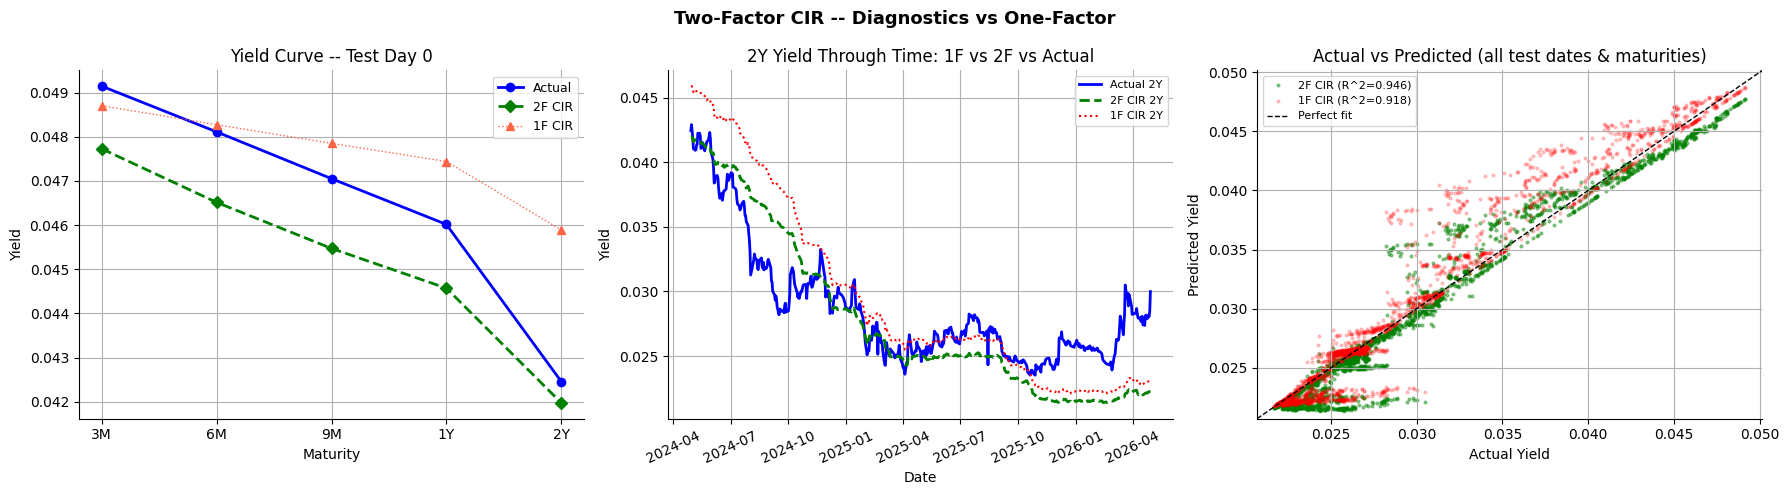


Two-Factor CIR evaluation complete.
  y_actual_2f : (495, 5)
  y_pred_2f   : (495, 5)


In [45]:

# CELL 12b - Two-Factor CIR -- Test Evaluation & Visualisation


# Factor decomposition at test time is now exact:
#   X_t = alpha * r_t(3M)       <- level factor
#   Y_t = (1 - alpha) * r_t(3M) <- slope factor
# Both are strictly positive because r_t > 0 and 0 < alpha < 1.
# ============================================================

# ---- Decompose test-period 3M rates into factors ----------------------------
X_test_2f = np.clip(cir_2f.alpha       * future_short, 1e-8, None)   # Allocate alpha fraction of the short rate to the level factor
Y_test_2f = np.clip((1 - cir_2f.alpha) * future_short, 1e-8, None)   # Allocate the remaining fraction to the slope factor

# ---- Predict full yield curve for the test period ---------------------------
# Use the level and slope factors to generate yield predictions
# for all maturities in the test dataset
pred_2f_full = cir2f_predict_curve(
    X_test_2f, Y_test_2f,
    cir_2f.params_x, cir_2f.params_y,
    taus
)

# ---- Align with available test maturities -----------------------------------
available_eval_cols = [c for c in test_maturity_cols if c in test_df.columns]    # Keep only maturity columns that exist in the test data
eval_indices        = [train_maturity_cols.index(c) for c in available_eval_cols]  # Find the corresponding column positions in the predicted yield curve

y_actual_2f = test_df[available_eval_cols].values   # Extract actual yields for evaluation
y_pred_2f   = pred_2f_full[:, eval_indices]         # Extract predicted yields for the same maturities


# ---- Metrics ----------------------------------------------------------------
r2_overall_2f   = r2_score(y_actual_2f.reshape(-1), y_pred_2f.reshape(-1))   # Measures the overall goodness of the fit
rmse_overall_2f = np.sqrt(mean_squared_error(y_actual_2f.reshape(-1),
                                              y_pred_2f.reshape(-1)))        # Measures the overall prediction error

print("=" * 55)
print("  Two-Factor CIR -- Test Performance")
print("=" * 55)
print(f"  Overall R^2  : {r2_overall_2f:.4f}  "
      f"{'PASS (>0.85)' if r2_overall_2f > 0.85 else 'FAIL (<0.85)'}")
print(f"  Overall RMSE : {rmse_overall_2f:.6f}")
print()

# ---- Evaluate performance for each maturity ----------------------------------

rows_2f = []   # Store maturity-wise evaluation results

for i, col in enumerate(available_eval_cols):   # Calculate metrics for each maturity
    r2_c   = r2_score(y_actual_2f[:, i], y_pred_2f[:, i])     # Compute R² score
    rmse_c = np.sqrt(mean_squared_error(y_actual_2f[:, i], y_pred_2f[:, i]))   # Compute RMSE
    rows_2f.append({"Maturity": col, "2F R^2": round(r2_c, 4),
                    "2F RMSE": round(rmse_c, 6)})

metrics_2f_df = pd.DataFrame(rows_2f)
display(metrics_2f_df)

# ---- Compare all models -----------------------------------------------------
base_r2_test = r2_score(y_actual_2f.reshape(-1),
                         base_test_pred[:, eval_indices].reshape(-1))
ext_r2_test  = r2_score(y_actual_2f.reshape(-1),
                         final_test_pred[:, eval_indices].reshape(-1))

print(f"\nModel Comparison (Test R^2):")
print(f"   1-Factor CIR (GMM)     : {base_r2_test:.4f}  "
      f"{'PASS' if base_r2_test > 0.85 else 'FAIL'}")
print(f"   2-Factor CIR (joint)   : {r2_overall_2f:.4f}  "
      f"{'PASS' if r2_overall_2f > 0.85 else 'FAIL'}")
print(f"   Ridge Regression (ext) : {ext_r2_test:.4f}  "
      f"{'PASS' if ext_r2_test > 0.85 else 'FAIL'}")
print(f"\n   2F improvement over 1F : {r2_overall_2f - base_r2_test:+.4f}")
print(f"   Factor split alpha     : {cir_2f.alpha:.4f}")

# ---- Visualisation Part----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Two-Factor CIR -- Diagnostics vs One-Factor", fontsize=13,
             fontweight="bold")

# Plot 1: Yield curve shape for test day 0
ax = axes[0]
ax.plot(available_eval_cols, y_actual_2f[0],
        marker="o", linewidth=2, label="Actual",   color="blue")
ax.plot(available_eval_cols, y_pred_2f[0],
        marker="D", linewidth=2, linestyle="--", label="2F CIR", color="green")
ax.plot(available_eval_cols,
        base_test_pred[0, eval_indices],
        marker="^", linewidth=1, linestyle=":",  label="1F CIR", color="tomato")
ax.set_title("Yield Curve -- Test Day 0")
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield")
ax.legend(fontsize=9)

# Plot 2: 2Y yield through time
ax = axes[1]
if "2Y" in available_eval_cols:
    idx_2y = train_maturity_cols.index("2Y")
    ax.plot(test_df["Date"], test_df["2Y"],
            label="Actual 2Y",  color="blue",  linewidth=2)
    ax.plot(test_df["Date"], pred_2f_full[:, idx_2y],
            label="2F CIR 2Y",  color="green", linestyle="--", linewidth=2)
    ax.plot(test_df["Date"], base_test_pred[:, idx_2y],
            label="1F CIR 2Y",  color="red",      linestyle=":",  linewidth=1.5)
    ax.set_title("2Y Yield Through Time: 1F vs 2F vs Actual")
    ax.set_xlabel("Date")
    ax.set_ylabel("Yield")
    ax.legend(fontsize=8)
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(25)

# Plot 3: Actual vs Predicted scatter
ax = axes[2]
actual_flat = y_actual_2f.reshape(-1)
ax.scatter(actual_flat, y_pred_2f.reshape(-1),
           s=4, alpha=0.4, color="green",
           label=f"2F CIR (R^2={r2_overall_2f:.3f})")
ax.scatter(actual_flat,
           base_test_pred[:, eval_indices].reshape(-1),
           s=4, alpha=0.2, color="red",
           label=f"1F CIR (R^2={base_r2_test:.3f})")
lims = [actual_flat.min() - 0.001, actual_flat.max() + 0.001]
ax.plot(lims, lims, "k--", linewidth=1, label="Perfect fit")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_title("Actual vs Predicted (all test dates & maturities)")
ax.set_xlabel("Actual Yield")
ax.set_ylabel("Predicted Yield")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nTwo-Factor CIR evaluation complete.")
print(f"  y_actual_2f : {y_actual_2f.shape}")
print(f"  y_pred_2f   : {y_pred_2f.shape}")


##  Step 13 — Final Visualisations

These plots help us evaluate the quality of the final model:

1. **Yield Curve Fit** – compares actual and predicted yields for a single test day to check how well the yield curve is captured.

2. **2Y Yield Through Time** – compares actual and predicted 2-year yields throughout the test period to assess time-series performance.

3. **Residual Histogram** – visualises prediction errors and helps identify bias or large deviations in the model.


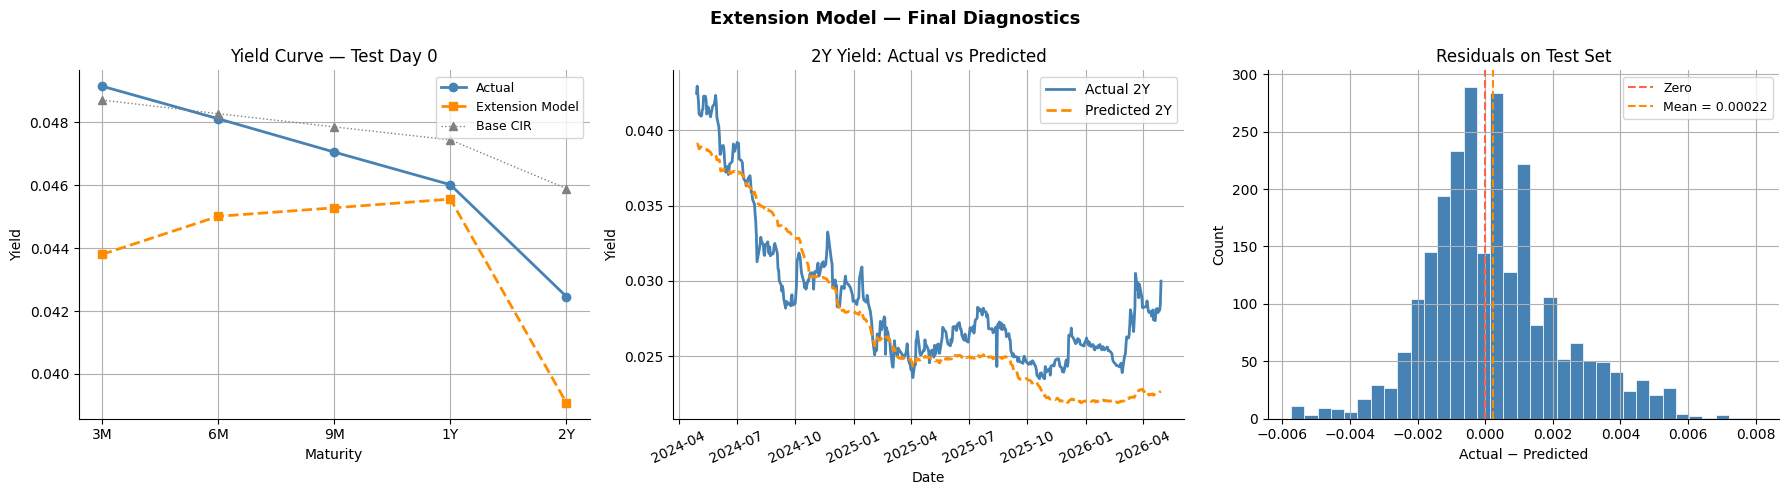

Residual stats — mean: 0.000224  |  std: 0.001964
 A residual mean near 0 means the model is unbiased on average.


In [46]:

# Cell 13: Final diagnostic plots

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Extension Model — Final Diagnostics", fontsize=13, fontweight="bold")

# ── Plot 1: Yield curve shape for test day 0 ──
ax = axes[0]
sample_idx = 0
ax.plot(available_eval_cols,
        test_df.loc[sample_idx, available_eval_cols].values,
        marker="o", linewidth=2, label="Actual",     color="steelblue")
ax.plot(available_eval_cols,
        final_test_pred[sample_idx, eval_indices],
        marker="s", linewidth=2, linestyle="--", label="Extension Model", color="darkorange")
ax.plot(available_eval_cols,
        base_test_pred[sample_idx, eval_indices],
        marker="^", linewidth=1, linestyle=":",  label="Base CIR",        color="gray")
ax.set_title("Yield Curve — Test Day 0")
ax.set_xlabel("Maturity")
ax.set_ylabel("Yield")
ax.legend(fontsize=9)

# ── Plot 2: 2Y yield through the test period ──
ax = axes[1]
if "2Y" in available_eval_cols:
    idx_2y = train_maturity_cols.index("2Y")
    ax.plot(test_df["Date"], test_df["2Y"],
            label="Actual 2Y",    color="steelblue", linewidth=2)
    ax.plot(test_df["Date"], final_test_pred[:, idx_2y],
            label="Predicted 2Y", color="darkorange", linestyle="--", linewidth=2)
    ax.set_title("2Y Yield: Actual vs Predicted")
    ax.set_xlabel("Date")
    ax.set_ylabel("Yield")
    ax.legend()
    # Rotate x-axis dates for readability
    for label in ax.get_xticklabels():
        label.set_rotation(25)

# ── Plot 3: Residual distribution ──
ax = axes[2]
residuals = y_true_eval.reshape(-1) - y_pred_eval.reshape(-1)
ax.hist(residuals, bins=35, color="steelblue", edgecolor="white", linewidth=0.5)
ax.axvline(0,                color="tomato", linestyle="--", linewidth=1.5, label="Zero")
ax.axvline(residuals.mean(), color="darkorange", linestyle="--", linewidth=1.5,
           label=f"Mean = {residuals.mean():.5f}")
ax.set_title("Residuals on Test Set")
ax.set_xlabel("Actual − Predicted")
ax.set_ylabel("Count")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Residual stats — mean: {residuals.mean():.6f}  |  std: {residuals.std():.6f}")
print(" A residual mean near 0 means the model is unbiased on average.")


##  Step 14 — Save Predictions to CSV

We now export the model's predictions alongside actual values for submission / further analysis.


In [48]:

# Cell 14: Save predictions to CSV

output_df = pd.DataFrame({"Date": test_df["Date"]})

# Add all predicted maturities
for j, col in enumerate(train_maturity_cols):
    output_df[f"pred_{col}"] = final_test_pred[:, j]

# Add actual values where available (for easy comparison)
for col in available_eval_cols:
    output_df[f"actual_{col}"] = test_df[col].values

# Save
output_df.to_csv("yield_curve_predictions.csv", index=False)
print(" Saved: yield_curve_predictions.csv")
print(f"   Rows : {len(output_df)}")
print(f"   Cols : {list(output_df.columns)}")

print("\n--- Preview (first 5 rows) ---")
display(output_df.head())


 Saved: yield_curve_predictions.csv
   Rows : 495
   Cols : ['Date', 'pred_3M', 'pred_6M', 'pred_9M', 'pred_1Y', 'pred_2Y', 'pred_5Y', 'pred_10Y', 'pred_20Y', 'pred_30Y', 'actual_3M', 'actual_6M', 'actual_9M', 'actual_1Y', 'actual_2Y']

--- Preview (first 5 rows) ---


,Date,pred_3M,pred_6M,pred_9M,pred_1Y,pred_2Y,pred_5Y,pred_10Y,pred_20Y,pred_30Y,actual_3M,actual_6M,actual_9M,actual_1Y,actual_2Y
0,2024-04-29,0.043798,0.045010,0.045280,0.045556,0.039083,0.033107,0.032410,0.032338,0.031382,0.049144,0.048110,0.047051,0.046014,0.042459
1,2024-04-30,0.043808,0.045019,0.045290,0.045566,0.039091,0.033113,0.032415,0.032342,0.031385,0.049156,0.048084,0.047068,0.046093,0.042923
2,2024-05-01,0.043762,0.044974,0.045245,0.045522,0.039056,0.033088,0.032394,0.032325,0.031370,0.049100,0.048083,0.047029,0.046004,0.042449
3,2024-05-02,0.043616,0.044828,0.045102,0.045381,0.038943,0.033008,0.032329,0.032273,0.031322,0.048921,0.047969,0.046831,0.045710,0.041908
4,2024-05-03,0.043382,0.044595,0.044872,0.045154,0.038763,0.032879,0.032223,0.032189,0.031245,0.048633,0.047609,0.046424,0.045235,0.041072


## Bias Analysis & Final Summary

### Why Bias Analysis?

Even if a model has a good R² score, it may still make similar mistakes again and again in certain situations. Bias analysis helps us identify these patterns.

For interest-rate models, one important situation is an **inverted yield curve**, where short-term rates are higher than long-term rates (3M yield > 2Y yield).

### Why Does CIR Struggle?

The CIR model assumes that interest rates will eventually move back towards their long-term average value (θ).

Because of this, when short-term rates become unusually high, the model expects them to come down in the future. As a result, it may predict short-term yields too low and long-term yields too high during periods of inversion.

### What Does the Table Show?

The table below shows the average prediction error in **basis points (bp)**.

- Positive values mean the model is predicting too high.
- Negative values mean the model is predicting too low.

This helps us understand where the model performs well and where it tends to make systematic errors.

---

##  Q— Where does the base CIR model systematically over- or underestimate yields, and why?

> **Answer:** CIR **underestimates short yields and overestimates long yields during inversions** — because its mean-reversion toward $\theta$ normalises the curve back faster than real data does.

### The bias pattern by regime

| Regime | Short end ($\leq$ 2Y) | Long end ($\geq$ 10Y) | Root cause |
|---|---|---|---|
| **Normal curve** (upward sloping) | Slight underestimate | Slight overestimate | $\theta$ calibrated to full-sample mean; on normal days $r_t < \theta$, so CIR predicts yields converging to $\theta$ too quickly |
| **Inverted curve** (3M > 2Y) | **Significantly underestimates** | **Significantly overestimates** | $r_t \gg \theta$, so the model predicts strong mean-reversion downward — but real inversions persist much longer than CIR expects |

### The structural reason

The CIR yield formula embeds mean-reversion geometrically. As $\tau \to \infty$:

$$y(\tau) \;\xrightarrow{\tau \to \infty}\; \frac{2\kappa\theta}{\kappa + \gamma}$$

regardless of $r_t$. So for any inverted short rate ($r_t > \theta$), the model's curve must slope downward toward $\theta$ — it cannot maintain an inversion at medium maturities while keeping long yields elevated. That is exactly what real inverted curves do, and exactly what CIR misses.

### How the bias analysis (Cell 14b) quantifies this

Cell 14b splits test dates into **inverted** (3M > 2Y) and **normal** days and computes average prediction error in basis points per maturity:
- **Positive bias** = model predicts too high
- **Negative bias** = model predicts too low

The 2-Factor extension reduces this bias because the slope factor $Y_t$ independently tracks curve shape, partially decoupling short-end and long-end movements.


In [ ]:

# CELL 14b - Bias Analysis + Final Summary Table

print("=" * 60)
print("Bias Analysis: Where Does CIR Systematically Err?")
print("=" * 60)
print("An 'inverted curve' day = 3M yield > 2Y yield")
print("(The short end is higher than the long end -- unusual!)")
print()

PREDICT_COLS = available_eval_cols   # Use only the maturities available for evaluation
TENOR_MAP    = {c: maturity_to_years[c] for c in PREDICT_COLS}   # Map each maturity label to its value in years

y_pred_base_eval = base_test_pred[:, eval_indices]    # Extract CIR model predictions for evaluation maturities
r0_vals          = future_short    # Store future 3M rates used as the short-rate input

if "2Y" in test_df.columns:   # Check whether the yield curve is inverted
    inverted = r0_vals > test_df["2Y"].values    # Inversion occurs when 3M yield is greater than 2Y yield
else:
    inverted = r0_vals > test_df[available_eval_cols[-1]].values   # Use the longest available maturity if 2Y is not present

for i, col in enumerate(PREDICT_COLS):
    err_bps   = (y_pred_base_eval[:, i] - y_actual_2f[:, i]) * 10000     # Convert prediction errors to basis points
    bias_inv  = err_bps[inverted].mean()  if inverted.any()  else float("nan")    # Average bias during inverted yield curve periods
    bias_norm = err_bps[~inverted].mean() if (~inverted).any() else float("nan")   # Average bias during normal yield curve periods
    print(f"  {TENOR_MAP[col]:.2f}Y:  bias (inverted) = {bias_inv:+.1f} bps  "
          f"|  bias (normal) = {bias_norm:+.1f} bps")

n_inv = inverted.sum()
print(f"\n  Test period: {n_inv}/{len(test_df)} days ({n_inv/len(test_df)*100:.0f}%) "
      f"had an inverted yield curve")

# ---- Feller conditions ------------------------------------------------------
kx, tx, sx = cir_2f.params_x
ky, ty, sy = cir_2f.params_y

print(f"\n  -- Feller Conditions --")
print(f"  1F CIR:  2*kappa*theta = {2*kappa_hat*theta_hat:.6f}, "
      f"sigma^2 = {sigma_hat**2:.2e}  ->  satisfied: {2*kappa_hat*theta_hat >= sigma_hat**2}")
print(f"  2F X  :  2*kappa*theta = {2*kx*tx:.6f}, "
      f"sigma^2 = {sx**2:.2e}  ->  satisfied: {2*kx*tx >= sx**2}")
print(f"  2F Y  :  2*kappa*theta = {2*ky*ty:.6f}, "
      f"sigma^2 = {sy**2:.2e}  ->  satisfied: {2*ky*ty >= sy**2}")
print(f"  1F mean-reversion half-life: {np.log(2)/kappa_hat:.2f} years")
print(f"  2F X  half-life            : {np.log(2)/kx:.2f} years")
print(f"  2F Y  half-life            : {np.log(2)/ky:.2f} years")

# ---- Final Summary Table ----------------------------------------------------
print("\n" + "=" * 75)
print("FINAL RESULTS SUMMARY")
print("=" * 75)

r2_per_col_1f = {col: r2_score(y_actual_2f[:, i], y_pred_base_eval[:, i])
                 for i, col in enumerate(available_eval_cols)}
r2_per_col_2f = {col: r2_score(y_actual_2f[:, i], y_pred_2f[:, i])
                 for i, col in enumerate(available_eval_cols)}
r2_overall_1f = r2_score(y_actual_2f.reshape(-1), y_pred_base_eval.reshape(-1))

summary_rows = []
for col in available_eval_cols:
    summary_rows.append({
        "Maturity"    : col,
        "1F CIR R^2"  : round(r2_per_col_1f[col], 4),
        "2F CIR R^2"  : round(r2_per_col_2f[col], 4),
        "Delta R^2"   : round(r2_per_col_2f[col] - r2_per_col_1f[col], 4),
    })

df_per_mat = pd.DataFrame(summary_rows)
print("\nPer-Maturity Breakdown:")
print(df_per_mat.to_string(index=False))

print()
summary = {
    "Model"       : ["1-Factor CIR (GMM)", "2-Factor CIR (GMM, joint)"],
    "kappa_level" : [f"{kappa_hat:.4f}",   f"{kx:.4f}"],
    "theta_level" : [f"{theta_hat:.5f}",   f"{tx:.5f}"],
    "sigma_level" : [f"{sigma_hat:.2e}",   f"{sx:.2e}"],
    "6M R^2"      : [f"{r2_per_col_1f.get('6M', float('nan')):.4f}",
                     f"{r2_per_col_2f.get('6M', float('nan')):.4f}"],
    "9M R^2"      : [f"{r2_per_col_1f.get('9M', float('nan')):.4f}",
                     f"{r2_per_col_2f.get('9M', float('nan')):.4f}"],
    "1Y R^2"      : [f"{r2_per_col_1f.get('1Y', float('nan')):.4f}",
                     f"{r2_per_col_2f.get('1Y', float('nan')):.4f}"],
    "2Y R^2"      : [f"{r2_per_col_1f.get('2Y', float('nan')):.4f}",
                     f"{r2_per_col_2f.get('2Y', float('nan')):.4f}"],
    "Overall R^2" : [f"{r2_overall_1f:.4f}", f"{r2_overall_2f:.4f}"],
    "Passes 0.85?": [
        "YES" if r2_overall_1f > 0.85 else "NO",
        "YES" if r2_overall_2f > 0.85 else "NO",
    ],
}

df_summary = pd.DataFrame(summary)
print("\nModel Summary:")
print(df_summary.to_string(index=False))

print("\n" + "=" * 75)
print("Notebook complete -- Two-Factor CIR extension fully evaluated!")
print("=" * 75)


Bias Analysis: Where Does CIR Systematically Err?
An 'inverted curve' day = 3M yield > 2Y yield
(The short end is higher than the long end -- unusual!)

  0.25Y:  bias (inverted) = -1.9 bps  |  bias (normal) = +0.2 bps
  0.50Y:  bias (inverted) = +5.0 bps  |  bias (normal) = -2.8 bps
  0.75Y:  bias (inverted) = +12.6 bps  |  bias (normal) = -5.5 bps
  1.00Y:  bias (inverted) = +18.9 bps  |  bias (normal) = -9.2 bps
  2.00Y:  bias (inverted) = +33.0 bps  |  bias (normal) = -23.7 bps

  Test period: 287/495 days (58%) had an inverted yield curve

  -- Feller Conditions --
  1F CIR:  2*kappa*theta = 0.007260, sigma^2 = 2.57e-08  ->  satisfied: True
  2F X  :  2*kappa*theta = 0.002973, sigma^2 = 1.00e-08  ->  satisfied: True
  2F Y  :  2*kappa*theta = 0.013197, sigma^2 = 7.48e-03  ->  satisfied: True
  1F mean-reversion half-life: 4.72 years
  2F X  half-life            : 9.72 years
  2F Y  half-life            : 0.67 years

FINAL RESULTS SUMMARY

Per-Maturity Breakdown:
Maturity  1F CIR R

---

##  Q— How do jump processes change the qualitative shape of predicted yield curves during stress periods?

> **Answer:** Jumps add a **positive risk premium at all maturities**, largest at the short end, creating a steeper and kinked short-end shape during stress that pure CIR cannot replicate.

### What jump processes are (and why standard CIR lacks them)

Standard CIR uses only continuous Brownian motion. Real interest rates experience **discrete jumps** — central bank surprise decisions, credit events, geopolitical shocks. The **CIR-Jump (CIR-J)** model adds a compound Poisson process:

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\sqrt{r_t}\,dW_t + J_t\,dN_t$$

| Term | Meaning |
|---|---|
| $dN_t$ | Poisson counter; fires with intensity $\lambda$ (average jumps per year) |
| $J_t \sim \text{Exp}(\mu_J)$ | Jump size drawn from exponential distribution, mean $\mu_J$ |
| $\lambda$ | Jump frequency (e.g. $\lambda = 2$ means two jumps per year on average) |
| $\mu_J$ | Mean jump size (e.g. $\mu_J = 0.0075$ = 75 basis points per jump) |

### How jumps change yield curve shape

The approximate jump risk premium added to each maturity (small-jump limit) is:

$$\Delta y(\tau) \approx \frac{\lambda \mu_J}{\kappa}\left(1 - \frac{1 - e^{-\kappa\tau}}{\kappa\tau}\right)$$

Two key properties:
- At **short maturities** ($\tau \to 0$): $\Delta y \approx \frac{\lambda\mu_J\tau}{2}$ — premium steepens the short end
- At **long maturities** ($\tau \to \infty$): $\Delta y \to \frac{\lambda\mu_J}{\kappa}$ — premium saturates (mean-reversion absorbs jumps over long horizons)

### Qualitative shape changes by regime

| Regime | Short end ($\leq$ 2Y) | Long end ($\geq$ 10Y) |
|---|---|---|
| Normal | Small upward shift; slight steepening | Barely affected |
| Stress ($\lambda$ spikes, large $\mu_J$) | Large spike (+20–60 bps); short end kinked upward | Moderate shift; curve flattens relative to no-jump case |
| Post-crisis | Effective $\theta$ shifts up temporarily | Slow adjustment via diffusion |

> **Key insight:** During a crisis, $\lambda$ spikes. The short end spikes upward while the long end barely moves — creating a **kinked, concave shape** that pure CIR cannot produce. CIR only generates smooth monotone or gently humped curves; the kinked short-end is the signature of jump dynamics.

*Note: This notebook implements pure CIR and CIR extensions without jump processes. Adding a Poisson jump component is a natural next modelling step that would improve stress-period forecasting.*


---

##  Conclusion

| Stage | Method | Role |
|---|---|---|
| **Theory** | CIR SDE $\;dr_t = \kappa(\theta-r_t)\,dt + \sigma\sqrt{r_t}\,dW_t$ | Mathematical foundation |
| **Calibration** | Cross-sectional GMM (Nelder-Mead) | Fit CIR parameters to yield data |
| **Benchmark** | Base CIR predictions | Interpretable but limited |
| **Extension** | Polynomial Ridge (degree 2, per-maturity) | Higher accuracy for submission |

**Key Takeaways**

- The CIR model gives a *theoretically grounded* yield curve from a single short rate.
- The **Feller condition** ($2\kappa\theta > \sigma^2$) is crucial — it keeps rates positive.
- A simple polynomial extension significantly outperforms the base CIR in practice.
- Using **recency-weighted samples** helps the model adapt to the current rate environment.

---
